In [1]:
# Run this cell for direct results we gain, we can use this data without training the model next time

model_1_results = {'accuracy': 78.30994306897921,
 'precision': 0.7795707979763848,
 'recall': 0.7830994306897922,
 'f1': 0.7808049408223194}

baseline_results = {'accuracy': 72.1832384482987,
 'precision': 0.7186466952323352,
 'recall': 0.7218323844829869,
 'f1': 0.6989250353450294}

model_2_results = {'accuracy': 71.36568251026083,
 'precision': 0.7141154400849147,
 'recall': 0.7136568251026082,
 'f1': 0.7110898400947387}

model_3_results ={'accuracy': 69.36568251026083,
 'precision': 0.6741154400849147,
 'recall': 0.6836568251026082,
 'f1': 0.6710898400947387}

model_4_results = {'accuracy': 73.00079438633655,
 'precision': 0.7293680260128934,
 'recall': 0.7300079438633655,
 'f1': 0.726385407957773}

model_5_results = {'accuracy': 82.92069376406725,
 'precision': 0.8280467114242507,
 'recall': 0.8292069376406725,
 'f1': 0.8283436097785153}

Let's make PubMed abstracts easier to read!

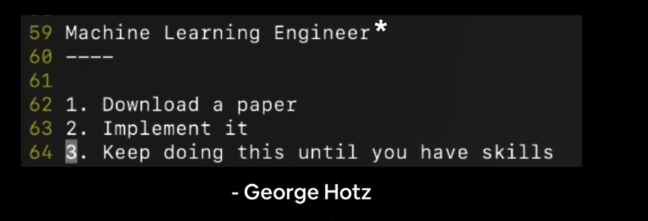

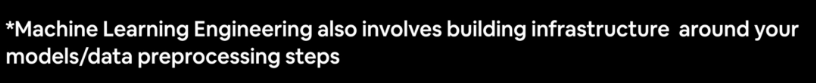

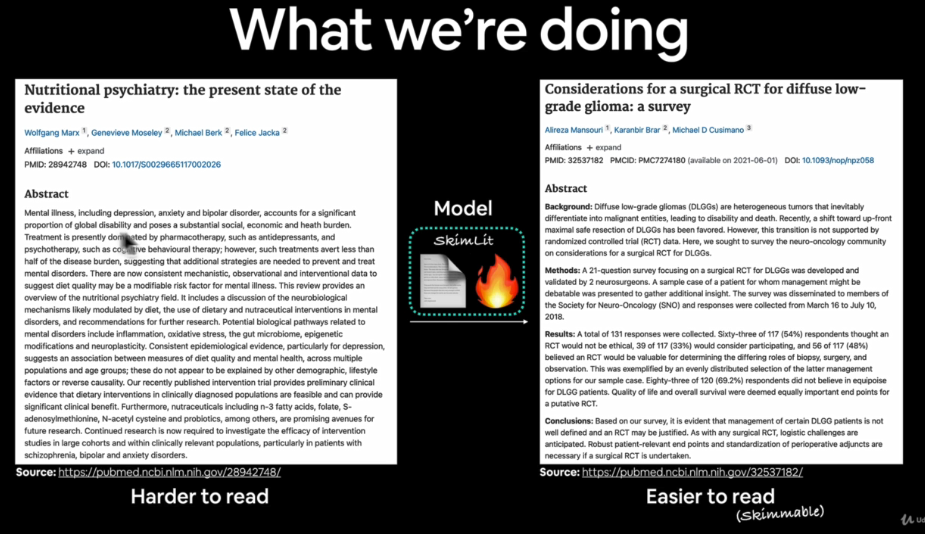

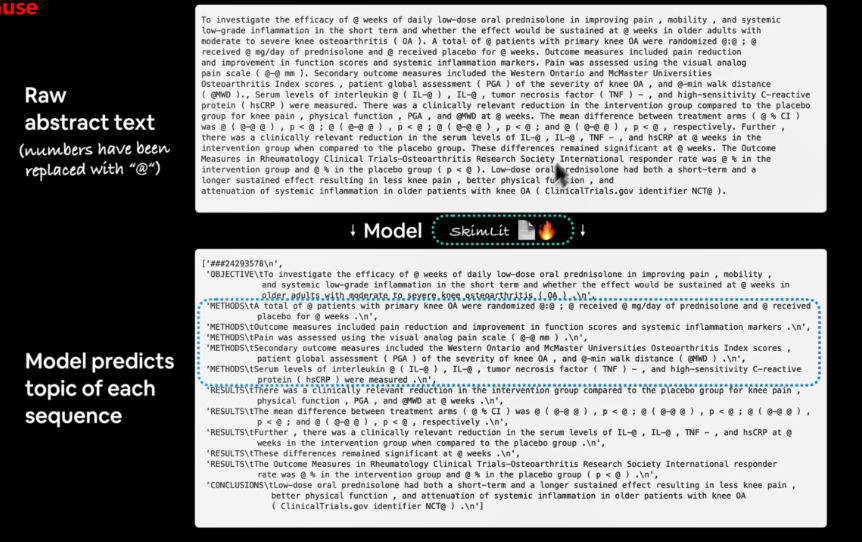

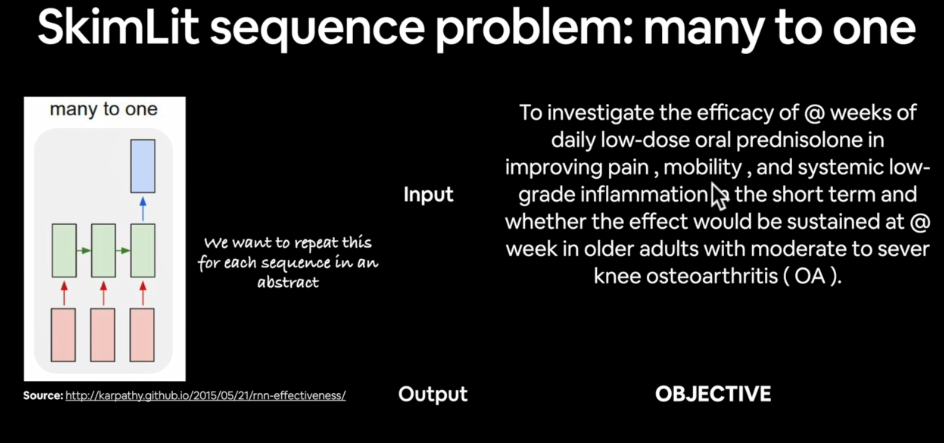

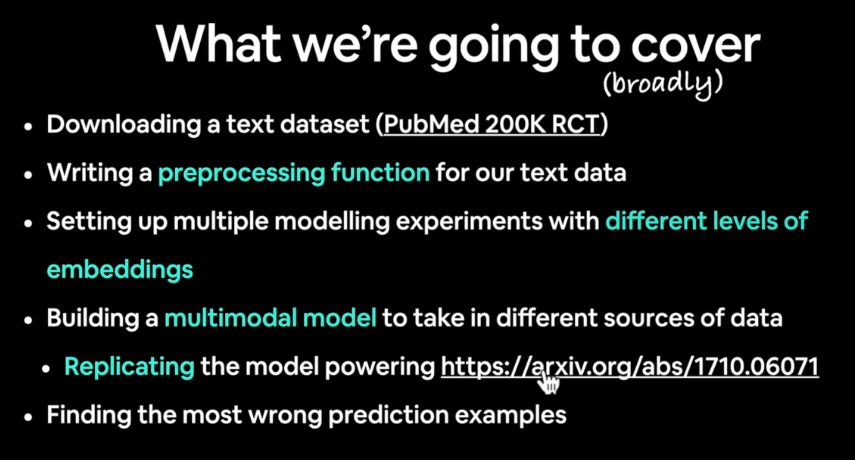

>read through this for better understanding:- https://arxiv.org/pdf/1612.05251

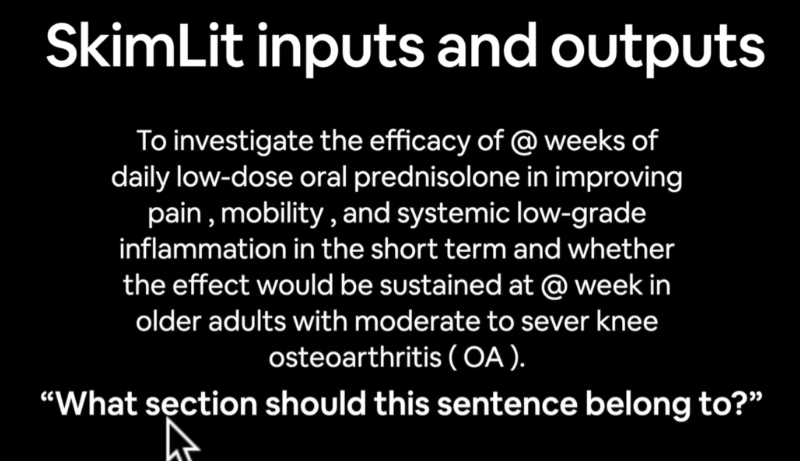

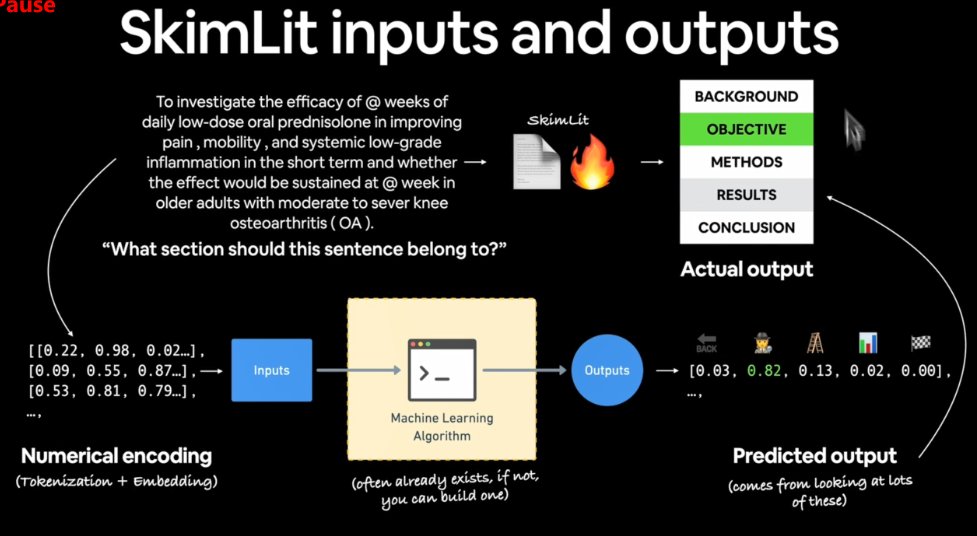

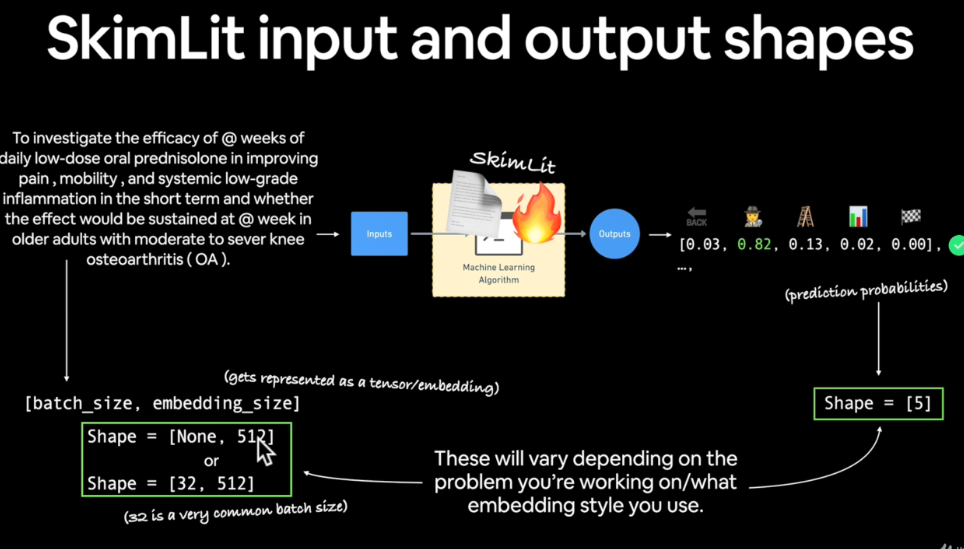

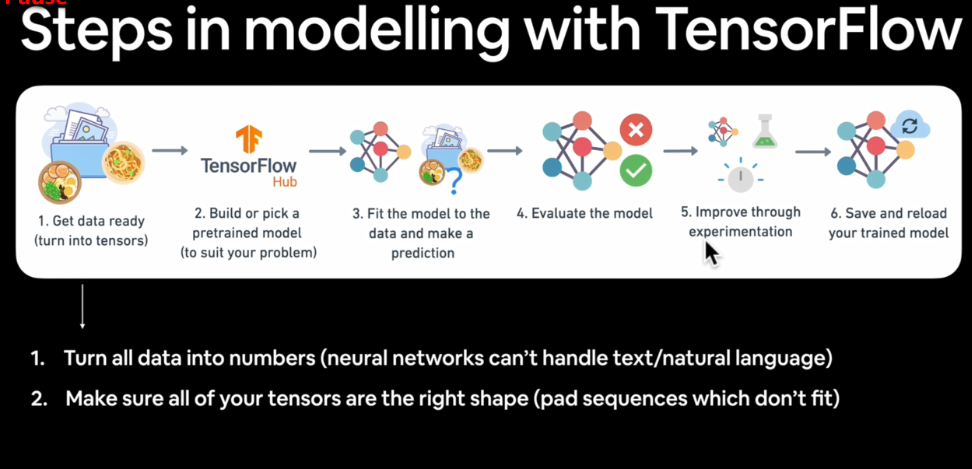

<h1 style="color:red">lec 004:-Setting up our notebook for Milestone Project 2 (getting the data)</h1>

# Milestone Project 2: Skimlit 📃🔥

The purpose of this notebook is to build an NLP model to make reading medical abstracts easier.

The paper we're replicating (the source of the dataset that we'll be using) is available here: https://arxiv.org/abs/1710.06071

And reading through the paper above, we see that the model architecture that they use to achieve their best results is available here: https://arxiv.org/abs/1612.05251

📖**Resources:** If you want to find the ground truth for this notebook (with lots of diagrams and text annotations) see the Github: https://github.com/mrdbourke/tensorflow-deep-learning/blob/main/09_SkimLit_nlp_milestone_project_2.ipynb

## Confirm access to a GPU

In [2]:
!nvidia-smi -L

GPU 0: Tesla T4 (UUID: GPU-cab788b0-7c97-7b88-b8c3-999365cb6ddd)


## Get data

SInce we'll be replicating the paper above (PubMed 200k RCT), let's download the dataset they used.

We can do so from the authors GitHub: https://github.com/Franck-Dernoncourt/pubmed-rct

In [3]:
!git clone https://github.com/Franck-Dernoncourt/pubmed-rct
!ls pubmed-rct

Cloning into 'pubmed-rct'...
remote: Enumerating objects: 39, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 39 (delta 8), reused 5 (delta 5), pack-reused 25 (from 1)
Receiving objects: 100% (39/39), 177.08 MiB | 16.05 MiB/s, done.
Resolving deltas: 100% (15/15), done.
PubMed_200k_RCT
PubMed_200k_RCT_numbers_replaced_with_at_sign
PubMed_20k_RCT
PubMed_20k_RCT_numbers_replaced_with_at_sign
README.md


In [4]:
# Check what files are in the PubMed_20K dataset
!ls pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/

dev.txt  test.txt  train.txt


In [5]:
# Start our experiments using the 20k dataset with number replaced by '@' sign
data_dir = "/content/pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/"

In [6]:
# Check all of the filenames in the target directory
import os
filenames = [data_dir+ filename for filename in os.listdir(data_dir)]
filenames

['/content/pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/test.txt',
 '/content/pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/train.txt',
 '/content/pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/dev.txt']

<h1 style="color:red">lec 005:-Visualising examples from the dataset (becoming one with the data)</h1>

## Preprocess data

Now we've got some text data, it's time to become one with it.

And one of the best ways to become one with the data is to...

> Visualize, visualize, visualize

So with that in mind, let's write function to read in all of the lines of target text file.

In [7]:
# Create function to read the lines of a document
def get_lines(filename):
  """
  Reads in a text file and returns a list of lines.

  Args:
    filename (str): path of file to read in.

  Returns:
    list: list of lines in the text file.
  """
  with open(filename, "r") as f:
    return f.readlines()

In [8]:
# Let's read in the training lines
train_lines = get_lines(data_dir+"train.txt") # read the lines with the training files
train_lines[:20]

['###24293578\n',
 'OBJECTIVE\tTo investigate the efficacy of @ weeks of daily low-dose oral prednisolone in improving pain , mobility , and systemic low-grade inflammation in the short term and whether the effect would be sustained at @ weeks in older adults with moderate to severe knee osteoarthritis ( OA ) .\n',
 'METHODS\tA total of @ patients with primary knee OA were randomized @:@ ; @ received @ mg/day of prednisolone and @ received placebo for @ weeks .\n',
 'METHODS\tOutcome measures included pain reduction and improvement in function scores and systemic inflammation markers .\n',
 'METHODS\tPain was assessed using the visual analog pain scale ( @-@ mm ) .\n',
 'METHODS\tSecondary outcome measures included the Western Ontario and McMaster Universities Osteoarthritis Index scores , patient global assessment ( PGA ) of the severity of knee OA , and @-min walk distance ( @MWD ) .\n',
 'METHODS\tSerum levels of interleukin @ ( IL-@ ) , IL-@ , tumor necrosis factor ( TNF ) - , and 

In [9]:
len(train_lines)

210040

Let's think about how we want our data to look...

How I think our data would be best represented...

```
[{'line_number':0,
  'target': 'BACKGROUND',
  'text':"Emotional eating is associated with overeating and the development of obesity .\n",
  'total_lines':11}]
```


<h1 style="color:red">lec 006:-Writing a preprocessing function to structure our data for modelling</h1>

In [10]:
def preprocess_text_with_line_numbers(filename):
  """
  Returns a list of dictionaries of abstarct line data.

  Takes in filename, reads it contents and sorts through each line,
  extracting the target label, text, line number and how many sentences.
  """
  input_lines = get_lines(filename) # get all lines from filenames
  abstract_lines = "" # create an empty abstract
  abstract_samples = [] # create an empty list of abstracts

  # Loop through each line in the target file
  for line in input_lines:
    if line.startswith("###"): # check to see if this is an id line
      abstract_id = line
      abstract_lines = "" # reset the abstract string  if the line is an ID line
    elif line.isspace(): # Check to see if line is a new line
      abstract_line_split = abstract_lines.splitlines() # split abstract into separate lines

      # Iterate through each line in a single abstract and count them at the same time
      for abstract_line_number, abstract_line in enumerate(abstract_line_split):
        line_data = {} # create an empty dictionary for each line
        target_text_split = abstract_line.split("\t") # split target label from text based on tab
        line_data["target"] = target_text_split[0] # add target label to dictionary
        line_data["text"] = target_text_split[1].lower() # get target text and lower it
        line_data["line_number"] = abstract_line_number # what number line does the line appear in abstract
        line_data["total_lines"] = len(abstract_line_split) - 1 # how many total lines are there in the target abstract? (start from 0)
        abstract_samples.append(line_data) # add line data to abstract sample list
    else: # if the above conditions aren't fulfilled, the line contains a labelled sentence
      abstract_lines+=  line;

  return abstract_samples

In [11]:
# Get data from files and preprocess it
%%time
train_samples = preprocess_text_with_line_numbers(data_dir+"train.txt")
val_samples = preprocess_text_with_line_numbers(data_dir+"dev.txt") # dev is another name for val
test_samples = preprocess_text_with_line_numbers(data_dir+"test.txt")

print(len(train_samples),len(val_samples),len(test_samples))

180040 30212 30135
CPU times: user 315 ms, sys: 81.9 ms, total: 397 ms
Wall time: 397 ms


In [12]:
# Check the first abstract of our training data
train_samples[:14]

[{'target': 'OBJECTIVE',
  'text': 'to investigate the efficacy of @ weeks of daily low-dose oral prednisolone in improving pain , mobility , and systemic low-grade inflammation in the short term and whether the effect would be sustained at @ weeks in older adults with moderate to severe knee osteoarthritis ( oa ) .',
  'line_number': 0,
  'total_lines': 11},
 {'target': 'METHODS',
  'text': 'a total of @ patients with primary knee oa were randomized @:@ ; @ received @ mg/day of prednisolone and @ received placebo for @ weeks .',
  'line_number': 1,
  'total_lines': 11},
 {'target': 'METHODS',
  'text': 'outcome measures included pain reduction and improvement in function scores and systemic inflammation markers .',
  'line_number': 2,
  'total_lines': 11},
 {'target': 'METHODS',
  'text': 'pain was assessed using the visual analog pain scale ( @-@ mm ) .',
  'line_number': 3,
  'total_lines': 11},
 {'target': 'METHODS',
  'text': 'secondary outcome measures included the western ontari

<h1 style="color:red">lec 007:-Performing visual data analysis on our preprocessed text</h1>

Now that our data in the format of a list of dictionaries, how about we turn it into a DataFrame to further visualize it?

In [12]:
import pandas as pd
train_df = pd.DataFrame(train_samples)
val_df = pd.DataFrame(val_samples)
test_df = pd.DataFrame(test_samples)

train_df.head(14)

,target,text,line_number,total_lines
0,OBJECTIVE,to investigate the efficacy of @ weeks of dail...,0,11
1,METHODS,a total of @ patients with primary knee oa wer...,1,11
2,METHODS,outcome measures included pain reduction and i...,2,11
3,METHODS,pain was assessed using the visual analog pain...,3,11
4,METHODS,secondary outcome measures included the wester...,4,11
5,METHODS,"serum levels of interleukin @ ( il-@ ) , il-@ ...",5,11
6,RESULTS,there was a clinically relevant reduction in t...,6,11
7,RESULTS,the mean difference between treatment arms ( @...,7,11
8,RESULTS,"further , there was a clinically relevant redu...",8,11
9,RESULTS,these differences remained significant at @ we...,9,11


In [14]:
# Distribution of labels in training data
train_df.target.value_counts()

,count
target,
METHODS,59353
RESULTS,57953
CONCLUSIONS,27168
BACKGROUND,21727
OBJECTIVE,13839


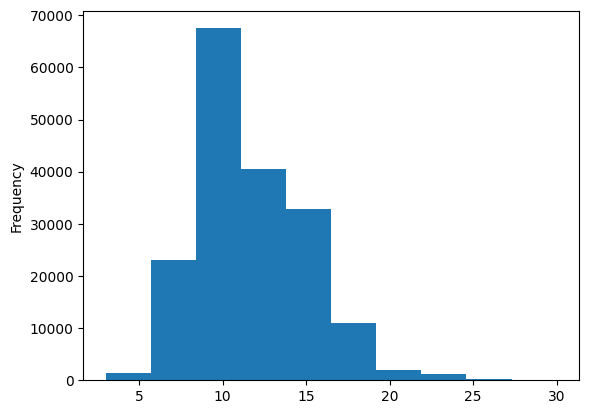

In [15]:
# Let's check the length of different lines
train_df["total_lines"].plot.hist();

In [13]:
# Convert abstract text lines into lists
train_sentences = train_df["text"].tolist()
val_sentences = val_df["text"].tolist()
test_sentences = test_df["text"].tolist()

len(train_sentences), len(test_sentences), len(val_sentences)


(180040, 30135, 30212)

<h1 style="color:red">lec 008:-Turning our target labels into numbers (ML models require numbers)</h1>

## Make numeric labels (ML models require numeric labels)

In [14]:
# One hot encode labels
from sklearn.preprocessing import OneHotEncoder
one_hot_encoder = OneHotEncoder(sparse_output=False)
train_labels_one_hot = one_hot_encoder.fit_transform(train_df["target"].to_numpy().reshape(-1,1))
test_labels_one_hot = one_hot_encoder.transform(test_df["target"].to_numpy().reshape(-1,1))
val_labels_one_hot = one_hot_encoder.transform(val_df["target"].to_numpy().reshape(-1,1))

# Check what one hot encoded look like
train_labels_one_hot

array([[0., 0., 0., 1., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0.],
       ...,
       [0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0.]])

## Label encode labels

In [15]:
# Extract labels ("target" columns) and encode them into integers
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

train_labels_encoded = label_encoder.fit_transform(train_df["target"].to_numpy())
test_labels_encoded  = label_encoder.transform(test_df["target"].to_numpy())
val_labels_encoded   = label_encoder.transform(val_df["target"].to_numpy())

# Check what training labels look like
train_labels_encoded

array([3, 2, 2, ..., 4, 1, 1])

In [16]:
# Get class names and number of classes from LabelEncoder instance
num_classes = len(label_encoder.classes_)
class_names = label_encoder.classes_
num_classes, class_names

(5,
 array(['BACKGROUND', 'CONCLUSIONS', 'METHODS', 'OBJECTIVE', 'RESULTS'],
       dtype=object))

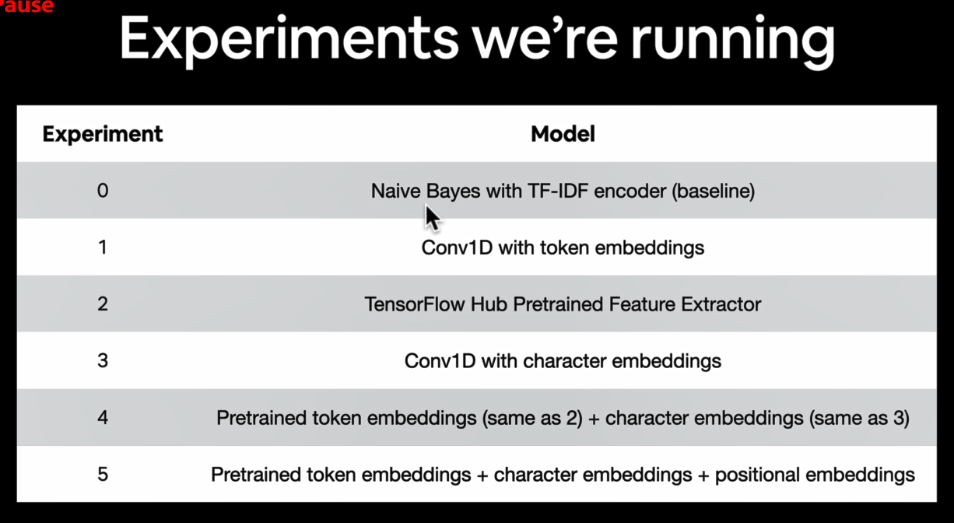

<h1 style="color:red">lec 009:-Model 0_ Creating, fitting and evaluating a baseline model for SkimLit</h1>

## Starting a series of modelling experiments...

As usual, we're going to be trying out bunch of different models and seeing which one works best.

And as always, we're going to start with a baseline (TF-IDF Multinomial Naive Bayes classifier).

## Model 0: Getting a baseline

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

# Create a pipeline
model_0 = Pipeline([
    ("tfidf", TfidfVectorizer()), # convert words to numbers using tfidf
    ("clf", MultinomialNB()) # model the
])

# Fit the pipeline to the training data
model_0.fit(X = train_sentences,
            y = train_labels_encoded)

Pipeline(steps=[('tfidf', TfidfVectorizer()), ('clf', MultinomialNB())])

In [21]:
# Evaluate baseline model on validation dataset
model_0.score(X = val_sentences,
              y = val_labels_encoded)

0.7218323844829869

In [22]:
# Make predictions using our baseline model
baseline_preds = model_0.predict(val_sentences)
baseline_preds

array([4, 1, 3, ..., 4, 4, 1])

### Download helper functions script

In the previous module, we wrote a function to compare predictions across different metrics (accuracy, precision, recall and f1) and rather than rewriting it here, let's download it from our helper function script: https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/extras/helper_functions.py

In [17]:
!wget "https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/extras/helper_functions.py"

--2026-03-29 04:49:23--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/extras/helper_functions.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10246 (10K) [text/plain]
Saving to: ‘helper_functions.py’

helper_functions.py 100%[===================>]  10.01K  --.-KB/s    in 0s      

2026-03-29 04:49:23 (122 MB/s) - ‘helper_functions.py’ saved [10246/10246]



In [18]:
from helper_functions import calculate_results

In [25]:
# Calculate baseline results
baseline_results = calculate_results(y_true = val_labels_encoded,
                                     y_pred = baseline_preds)

baseline_results

{'accuracy': 72.1832384482987,
 'precision': 0.7186466952323352,
 'recall': 0.7218323844829869,
 'f1': 0.6989250353450294}

<h1 style="color:red">lec 010:-Preparing our data for deep sequence models</h1>

## Preparing our data (the text) for deep sequence models

Before we start building deeper models, we've got to create vectorization and embedding layers.

In [19]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers

In [20]:
# How long is each sentence on average? we're counting number of words not characters
avg_sent_len=round(sum([len(i.split()) for i in train_sentences])/len(train_sentences))
avg_sent_len

26

In [21]:
sent_lens = [len(i.split()) for i in train_sentences]

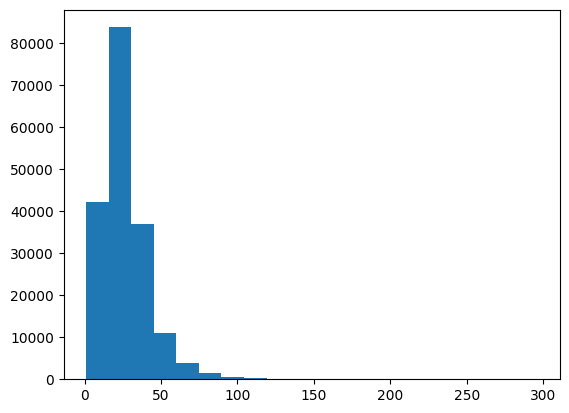

In [22]:
# What's the distribution look like?
import matplotlib.pyplot as plt
plt.hist(sent_lens,bins=20);

In [23]:
# How long of a sentence length covers 95% of examples?
np.quantile(sent_lens,0.95)

np.float64(55.0)

In [24]:
# How long of a sentence length covers 95% of examples?
output_seq_len = np.percentile(sent_lens,95)
output_seq_len

np.float64(55.0)

In [32]:
# Maximum sequence length in the training set
max(sent_lens)

296

<h1 style="color:red">lec 011:-Creating a text vectoriser to map our tokens (text) to numbers</h1>

### Create a texy vectorizer layer

We want to make a layer which maps our texts from words to numbers.

In [25]:
# How many words are in our vocab? (taken from table 2 in: https://arxiv.org/pdf/1710.06071.pdf)
max_tokens = 68000

In [26]:
from tensorflow.keras.layers import TextVectorization

text_vectorizer = TextVectorization(max_tokens=max_tokens, # number of words in vocabulary
                                    output_sequence_length=int(output_seq_len), # desired output length of vectorize sequences
                                    output_mode='int',
                                    standardize='lower_and_strip_punctuation')


In [27]:
# Adapt text vectorizer to training sentences
text_vectorizer.adapt(train_sentences)

In [36]:
# Test out text vectorizer on random sentences
import random
target_sentence = random.choice(train_sentences)

print(f"Text:\n{target_sentence}")
print(f"\nLengthof text: {len(target_sentence.split())}")
print(f"\nVectorized text:\n{text_vectorizer([target_sentence])}")
#

Text:
we investigated whether respiratory muscle training may improve respiratory muscle and cough function , and potentially reduce pneumonia risk in acute stroke .

Lengthof text: 23

Vectorized text:
[[  43  446  180  589  368  155   91  218  589  368    3 1960  149    3
  1190  270 1445   73    5  229  276    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0]]


In [28]:
# How many words are in our training vocabulary
rct_20k_text_vocab = text_vectorizer.get_vocabulary()
print(f"Number of words in vocab: {len(rct_20k_text_vocab)}")
print(f"Top 5 words: {rct_20k_text_vocab[:5]}")
print(f"Least common words: {rct_20k_text_vocab[-5:]}")

Number of words in vocab: 64841
Top 5 words: ['', '[UNK]', np.str_('the'), np.str_('and'), np.str_('of')]
Least common words: [np.str_('aainduced'), np.str_('aaigroup'), np.str_('aachener'), np.str_('aachen'), np.str_('aaacp')]


In [38]:
# Get the config of our text vectorizer
text_vectorizer.get_config()

{'name': 'text_vectorization',
 'trainable': True,
 'dtype': {'module': 'keras',
  'class_name': 'DTypePolicy',
  'config': {'name': 'float32'},
  'registered_name': None},
 'max_tokens': 68000,
 'standardize': 'lower_and_strip_punctuation',
 'split': 'whitespace',
 'ngrams': None,
 'output_mode': 'int',
 'output_sequence_length': 55,
 'pad_to_max_tokens': False,
 'sparse': False,
 'ragged': False,
 'vocabulary': None,
 'idf_weights': None,
 'encoding': 'utf-8',
 'vocabulary_size': 64841}

<h1 style="color:red">lec 012:-Creating a custom token embedding layer with TensorFlow</h1>

`mask_zero=True` means **treat token `0` as padding and ignore it in downstream layers**.

Given:

```
[123, 4, 5, 6, 9, 0, 0, 0]
```

Internally, a **mask** is created:

```
[True, True, True, True, True, False, False, False]
```

Interpretation:

* `True` → real tokens (used in computation)
* `False` → padding (ignored)

Effect on layers:

**1. Embedding layer**

* Index `0` still maps to a vector
* But mask is attached and passed forward

**2. RNNs (LSTM/GRU)**

* Time steps with `0` are skipped
* No state updates for those positions
* Sequence effectively behaves like:

  ```
  [123, 4, 5, 6, 9]
  ```

**3. Attention / Transformers**

* Padding positions get zero attention weight
* They don’t influence output

**4. Loss computation (if masking is respected)**

* Padding tokens do not contribute to loss

Key constraint:

* `0` must be reserved **only for padding**
* It cannot represent a real word/token

If `mask_zero=False`:

* `[0,0,0]` would be treated as normal tokens
* Model would learn meaningless patterns from padding → noise injected into training


### Create custom text embedding layer

In [29]:
from tensorflow.keras.layers import Embedding

# creates token embedding layer
token_embed = Embedding(input_dim=len(rct_20k_text_vocab) + 1, # set input shape (length of our vocab) (here + 1 because we set mask_zero=True)
                        output_dim = 128, # Note: different embedding sizes result in drastically different numbers of parameters to train
                        mask_zero = True, # use masking to handle variable sequence length (save space)
                        name="token_embedding")
#

In [40]:
# Show example embedding
print(f"Sentence before vectorization:\n{target_sentence}")
vectorized_sentence = text_vectorizer([target_sentence])
print(f"\nSentence after vectorization (before embedding):\n{vectorized_sentence}\n")
embedded_sentence = token_embed(vectorized_sentence)
print(f"Sentence after embedding:\n{embedded_sentence}\n")
print(f"Embedded sentence shape: {embedded_sentence.shape}")


Sentence before vectorization:
we investigated whether respiratory muscle training may improve respiratory muscle and cough function , and potentially reduce pneumonia risk in acute stroke .

Sentence after vectorization (before embedding):
[[  43  446  180  589  368  155   91  218  589  368    3 1960  149    3
  1190  270 1445   73    5  229  276    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0]]

Sentence after embedding:
[[[ 0.02751021  0.02030427  0.04498917 ... -0.0391378  -0.02948246
   -0.04966744]
  [ 0.04794544  0.03337225  0.03062924 ... -0.04534482  0.00580437
   -0.02857997]
  [ 0.02070704 -0.01528769  0.03714546 ... -0.02455666  0.00119152
   -0.03102461]
  ...
  [ 0.01352279 -0.0024521  -0.00652729 ... -0.04172137  0.03811148
   -0.04259163]
  [ 0.01352279 -0.0024521  -0.00652729 ... -0.04172137  0.03811148
   -0.04259163]
  [ 0.01352279 -0.0024521 

<h1 style="color:red">lec 013:-Creating fast loading dataset with the TensorFlow tf.data API</h1>

## Creating datasets (making sure our data loads as fast as possible)

We're going to setup our data to run as fast as possible with the TensorFlow tf.data API, many of the steps  here are discussed at length in these two resources:
* https://www.tensorflow.org/guide/data_performance
* https://www.tensorflow.org/guide/data

In [30]:
# Turn our data into Tensorflow Datasets
train_dataset = tf.data.Dataset.from_tensor_slices((train_sentences,train_labels_one_hot))
valid_dataset = tf.data.Dataset.from_tensor_slices((val_sentences,val_labels_one_hot))
test_dataset = tf.data.Dataset.from_tensor_slices((test_sentences,test_labels_one_hot))

In [42]:
train_dataset, train_labels_one_hot.shape

(<_TensorSliceDataset element_spec=(TensorSpec(shape=(), dtype=tf.string, name=None), TensorSpec(shape=(5,), dtype=tf.float64, name=None))>,
 (180040, 5))

In [31]:
# Take the TensorSliceDataset's and turn them into perfected datasets
train_dataset = train_dataset.batch(32).prefetch(tf.data.AUTOTUNE) # we're not going to shuffle our data because order of our dataset in now actually important
valid_dataset = valid_dataset.batch(32).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

train_dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None,), dtype=tf.string, name=None), TensorSpec(shape=(None, 5), dtype=tf.float64, name=None))>

<h1 style="color:red">lec 014:-Model 1_ Building, fitting and evaluating a Conv1D with token embeddings</h1>

## Model 1: Conv1D with token embeddings

In [44]:
num_classes  # label_encoder.classes_

5

In [45]:
# Create 1D conv model to process sequences
inputs = layers.Input(shape=(1,),dtype=tf.string)
text_vectors = text_vectorizer(inputs) # vectorize text inputs
token_embeddings = token_embed(text_vectors) # Create embedding
x = layers.Conv1D(filters=64,kernel_size=5,activation="relu",padding="same")(token_embeddings)
x = layers.GlobalAveragePooling1D()(x) # Condense the output of our feature vector from conv layer
outputs = layers.Dense(num_classes,activation="softmax")(x)
model_1 = tf.keras.Model(inputs,outputs)

# Compile
model_1.compile(loss="categorical_crossentropy",
                optimizer = tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'conv1d' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


In [46]:
model_1.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization              │ (None, 55)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_embedding (Embedding)     │ (None, 55, 128)        │     8,299,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 55, 64)         │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,341,125 (31.82 MB)

 Trainable params: 8,341,125 (31.82 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
from helper_functions import create_tensorboard_callback
SAVE_DIR = "model_logs"

In [48]:
# Fit the model
history_model_1 = model_1.fit(train_dataset,
                              steps_per_epoch = int(0.1*len(train_dataset)), # we are only taking 10 percent of the training data because it's quite large 5627*32
                              epochs=3,
                              validation_data = valid_dataset,
                              callbacks = [create_tensorboard_callback(dir_name="model_logs",
                                                                     experiment_name="model_1_Conv1D")],
                              validation_steps =int(0.1*len(valid_dataset))) # only validate on 10% of batches

Saving TensorBoard log files to: model_logs/model_1_Conv1D/20260328-083825
Epoch 1/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 17s 19ms/step - accuracy: 0.6370 - loss: 0.9206 - val_accuracy: 0.7410 - val_loss: 0.6909
Epoch 2/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 20s 36ms/step - accuracy: 0.7562 - loss: 0.6565 - val_accuracy: 0.7723 - val_loss: 0.6392
Epoch 3/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7739 - loss: 0.6165 - val_accuracy: 0.7889 - val_loss: 0.6001


In [49]:
# Evaluate on whole validation dataset
model_1.evaluate(valid_dataset)

945/945 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.7869 - loss: 0.5989


[0.5989190936088562, 0.7869058847427368]

In [50]:
# Make predictions (our model predicts prediction probabilties for each class)
model_1_pred_probs = model_1.predict(valid_dataset)
model_1_pred_probs

945/945 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step


array([[4.4542459e-01, 1.3338043e-01, 5.0629858e-02, 3.4449983e-01,
        2.6065273e-02],
       [4.5379865e-01, 2.6029187e-01, 1.0821767e-02, 2.6580617e-01,
        9.2815459e-03],
       [2.1146849e-01, 5.5563441e-03, 2.8262038e-03, 7.8005725e-01,
        9.1681737e-05],
       ...,
       [4.1696194e-06, 6.0051685e-04, 4.5517739e-04, 2.9110440e-06,
        9.9893719e-01],
       [5.0832283e-02, 3.7859833e-01, 1.2992057e-01, 5.9755672e-02,
        3.8089308e-01],
       [1.4568172e-01, 7.4762160e-01, 3.7868761e-02, 3.5072029e-02,
        3.3755954e-02]], dtype=float32)

In [51]:
# Convert pred probs to classes
model_1_preds = tf.argmax(model_1_pred_probs,axis = 1)
model_1_preds

<tf.Tensor: shape=(30212,), dtype=int64, numpy=array([0, 0, 3, ..., 4, 4, 1])>

In [52]:
class_names

array(['BACKGROUND', 'CONCLUSIONS', 'METHODS', 'OBJECTIVE', 'RESULTS'],
      dtype=object)

In [53]:
# Calculate model_1 results
model_1_results = calculate_results(y_true=val_labels_encoded,
                                    y_pred=model_1_preds)

model_1_results

{'accuracy': 78.69058652191183,
 'precision': 0.7833728373237376,
 'recall': 0.7869058652191182,
 'f1': 0.7843001588523929}

In [54]:
baseline_results

{'accuracy': 72.1832384482987,
 'precision': 0.7186466952323352,
 'recall': 0.7218323844829869,
 'f1': 0.6989250353450294}

<h1 style="color:red">lec 015:-Preparing a pretrained embedding layer from TensorFlow Hub for Model 2</h1>

## Model 2: Feature extraction with pretrained token embeddings

Now let's use pretrained word embeddings from TensorFlow Hub, more specifically the universal sentence encoder: https://tfhub.dev/google/universal-sentence-encoder/4

The paper originally used GloVe embeddings, however, we're going to stick with the later created USE pretrained embeddings.

In [33]:
# Download pretrained TenserFlow Hub USE

import tensorflow as tf
import tensorflow_hub as hub

@tf.keras.utils.register_keras_serializable() # for saving the uselayer in keras model too
class USELayer(tf.keras.layers.Layer):
    def __init__(self,trainable=False,**kwargs):
        super().__init__(**kwargs)
        #self.use = hub.load("https://tfhub.dev/google/universal-sentence-encoder/4")
        self.use = hub.KerasLayer("https://tfhub.dev/google/universal-sentence-encoder/4",
                                  trainable=trainable)

    def call(self, inputs):
      with tf.device('/CPU:0'): # necessary becuase of XLA issues
        return self.use(inputs)

inputs = tf.keras.Input(shape=[], dtype=tf.string)
x = USELayer()(inputs)
x = tf.keras.layers.Dense(64, activation="relu")(x)
outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

model_2 = tf.keras.Model(inputs, outputs)

Now it’s clear.

---

## Why **model_1 works** but **model_2 fails**

### model_1

```text
TextVectorization → native TF ops
```

→ XLA-compatible
→ runs fine

---

### model_2

```text
USELayer (TF Hub SavedModel) → contains non-XLA ops + string ops
```

Specifically:

```text
tfhub + tf.string + internal ops → NOT XLA compatible
```

---

## Root cause (exact)

```text
XLA tries to compile TF Hub model → fails at _Arg (DT_STRING)
```

Even if you wrote:

```python
tf.config.optimizer.set_jit(False)
```

→ **too late / ineffective**

---

## Why your fix didn’t work

Because:

```text
XLA is enabled at runtime / graph level / environment level
```

and:

```text
TF Hub layers internally trigger graph compilation
```

---

## Correct fixes (only 2 real ones)

---

# ✅ FIX 1 (guaranteed)

### Disable XLA BEFORE TensorFlow loads

Put this at the VERY TOP:

```python
import os
os.environ["TF_XLA_FLAGS"] = "--tf_xla_enable_xla_devices=false"

import tensorflow as tf
```

Then:

```text
Restart runtime
```

---

# ✅ FIX 2 (clean workaround)

Force USE to run on CPU:

```python
class USELayer(tf.keras.layers.Layer):
    def __init__(self, trainable=False, **kwargs):
        super().__init__(**kwargs)
        self.use = hub.KerasLayer(
            "https://tfhub.dev/google/universal-sentence-encoder/4",
            trainable=trainable
        )

    def call(self, inputs):
        with tf.device('/CPU:0'):
            return self.use(inputs)
```

---

## Why this works

```text
CPU path → no XLA → no compilation → no error
```

---

## Important insight

```text
TextVectorization = pure TF ops → safe
TF Hub USE = external SavedModel → not XLA-safe
```

---

## Your mental mistake

```text
"string input causes issue"
```

Wrong.

```text
TF Hub + XLA causes issue
```

---

## Final verdict

```text
model_1 works → native TF pipeline
model_2 fails → TF Hub + XLA conflict
```

---

## Minimal fix (use this)

```python
class USELayer(tf.keras.layers.Layer):
    def __init__(self, trainable=False, **kwargs):
        super().__init__(**kwargs)
        self.use = hub.KerasLayer(
            "https://tfhub.dev/google/universal-sentence-encoder/4",
            trainable=trainable
        )

    def call(self, inputs):
        with tf.device('/CPU:0'):
            return self.use(inputs)
```

---

## Bottom line

```text
USE + GPU(XLA) = unstable
USE + CPU = stable
```


You can’t fine-tune the **Universal Sentence Encoder (USE)** loaded via `hub.load()` the way you’re trying. That specific module (`https://tfhub.dev/google/universal-sentence-encoder/4`) is **frozen**—it does not expose trainable variables.

### Why your current approach is not trainable

* `hub.load()` returns a **SavedModel** with **no trainable weights**
* `self.use.trainable = True` will not work because:

  * `self.use.trainable_variables == []`
* So backpropagation never updates it

---

## Correct way (if you want trainable TF Hub model)

Use `hub.KerasLayer` instead of `hub.load()` and choose a model that supports fine-tuning.

### Modify your layer

```python
class USELayer(tf.keras.layers.Layer):
    def __init__(self, trainable=False, **kwargs):
        super().__init__(**kwargs)
        self.use = hub.KerasLayer(
            "https://tfhub.dev/google/universal-sentence-encoder/4",
            trainable=trainable
        )

    def call(self, inputs):
        return self.use(inputs)
```

### Then enable trainability

```python
x = USELayer(trainable=True)(inputs)
```

---

## But here’s the catch

Even with `trainable=True`, **USE v4 still won’t fine-tune** meaningfully because:

* It’s exported as a **feature extractor**
* Most internal weights are not exposed for training

---

## If you actually want fine-tuning (real solution)

Use models designed for fine-tuning:

### Better alternatives:

* BERT from TF Hub:

  ```
  https://tfhub.dev/tensorflow/bert_en_uncased_L-12_H-768_A-12/3
  ```
* Or use HuggingFace:

  ```python
  from transformers import TFAutoModel
  model = TFAutoModel.from_pretrained("bert-base-uncased")
  ```

These:

* Have trainable transformer layers
* Support freezing/unfreezing
* Work like real fine-tuning pipelines

---

## Summary

* Your current USE model → **not trainable**
* `hub.load()` → always frozen
* `hub.KerasLayer(trainable=True)` → syntactically correct but **USE still effectively frozen**
* For real fine-tuning → **use BERT / transformer models**

---

## Minimal fix (what you asked vs what works)

If your goal is:

* **Feature extraction only** → USE is fine
* **Fine-tuning embeddings** → switch model, not code


<h1 style="color:red">lec 016:-Model 2_ Building, fitting and evaluating a Conv1D model with token embeddings</h1>

## Building and fitting an NLP feature extraction model using pretrained embeddings from TensorFlow Hub

In [56]:
# Define feature extraction model using TF Hub layer
inputs = layers.Input(shape=[], # some sort of empty list given in USE guide
                      dtype = tf.string)
pretrained_embedding = USELayer(trainable=False)(inputs) # tokenize text and create emedding of each sequence (512 long vector)
x = layers.Dense(128,activation="relu")(pretrained_embedding)
# Note: you could add more layers here if you wanted to
outputs = layers.Dense(num_classes, # we have 5 classes
                       activation ="softmax")(x)

model_2 = tf.keras.Model(inputs=inputs,
                         outputs=outputs,
                         name='model_2_USE_feature_extractor')

# Compile the model
model_2.compile(loss="categorical_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

In [57]:
model_2.summary()

Model: "model_2_USE_feature_extractor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None)                 │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ use_layer_1 (USELayer)          │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,309 (259.02 KB)

 Trainable params: 66,309 (259.02 KB)

 Non-trainable params: 0 (0.00 B)

In [60]:
tf.config.optimizer.set_jit(False) # do it just for string nor performance is going to reduce XLA boost (Linear accelerated algebra)

# Fit model_2 to the data
history_model_2 = model_2.fit(train_dataset, # our prefetch dataset
                              steps_per_epoch=int(0.1*len(train_dataset)),
                              epochs=3,
                              validation_data=valid_dataset,
                              validation_steps=int(0.1*len(valid_dataset)),
                              callbacks=[create_tensorboard_callback(SAVE_DIR,
                                                                      "model_2_feature_extraction")])


Saving TensorBoard log files to: model_logs/model_2_feature_extraction/20260328-084531
Epoch 1/3


InvalidArgumentError: Graph execution error:

Detected at node data defined at (most recent call last):
<stack traces unavailable>
Detected at node data defined at (most recent call last):
<stack traces unavailable>
Detected unsupported operations when trying to compile graph __inference_one_step_on_data_46591[] on XLA_GPU_JIT: _Arg (No registered '_Arg' OpKernel for XLA_GPU_JIT devices compatible with node {{node data}}
	 (OpKernel was found, but attributes didn't match) Requested Attributes: T=DT_STRING, _output_shapes=[[32]], _user_specified_name="data", index=0){{node data}}
The op is created at: 
File "<frozen runpy>", line 198, in _run_module_as_main
File "<frozen runpy>", line 88, in _run_code
File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, in <module>
File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 992, in launch_instance
File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelapp.py", line 712, in sta

In [ ]:
# Evaluate on the whole validation dataset
model_2.evaluate(valid_dataset)

In [ ]:
# Make predictions with feature extraction model
model_2_pred_probs = model_2.predict(valid_dataset)
model_2_pred_probs

In [ ]:
# Convert the prediction probabilities found with feature extraction model to labels
model_2_preds = tf.argmax(model_2_pred_probs,axis=1)
model_2_preds

In [ ]:
# Calculate results from TF Hub pretrained embeddings results on val set
model_2_results = calculate_results(y_true=val_labels_encoded,
                                    y_pred=model_2_preds)

model_2_results

In [ ]:
baseline_results

In [ ]:
model_1_results

<h1 style="color:red">lec 017:-Creating a character-level tokeniser with TensorFlow's TextVectorization layer</h1>

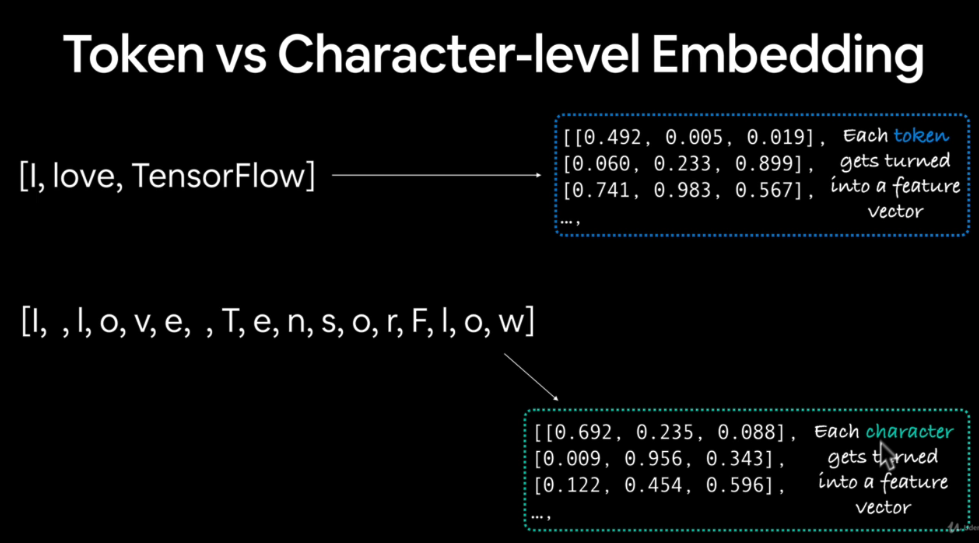

## Model 3: Conv1D with character embeddings

The paper which we're replicating states they used a combinations of token and character-level embeddings.

Previously we've used token-level embeddings but we'll need to do similar steps for characters if we want to use char-level embeddings.

### Creating a character level tokenizer

In [ ]:
train_sentences[:5]

In [ ]:
list(train_sentences[0])

In [ ]:
" ".join(list(train_sentences[0]))
#

In [35]:
# Make functions to split sentences into characters
def split_chars(text: str):
  return " ".join(list(text)) # first we're turning text into list it will do character wise then we are joining it again into string by introducing space in between individual characters

# Text splitting non-character-level sequence into characters
# split_chars(target_sentence)

In [36]:
# Split sequence-level data splits into character-level data splits
train_chars = [split_chars(sentence) for sentence in train_sentences]
test_chars = [split_chars(sentence) for sentence in test_sentences]
val_chars = [split_chars(sentence) for sentence in val_sentences]

print(train_chars[:5])

['t o   i n v e s t i g a t e   t h e   e f f i c a c y   o f   @   w e e k s   o f   d a i l y   l o w - d o s e   o r a l   p r e d n i s o l o n e   i n   i m p r o v i n g   p a i n   ,   m o b i l i t y   ,   a n d   s y s t e m i c   l o w - g r a d e   i n f l a m m a t i o n   i n   t h e   s h o r t   t e r m   a n d   w h e t h e r   t h e   e f f e c t   w o u l d   b e   s u s t a i n e d   a t   @   w e e k s   i n   o l d e r   a d u l t s   w i t h   m o d e r a t e   t o   s e v e r e   k n e e   o s t e o a r t h r i t i s   (   o a   )   .', 'a   t o t a l   o f   @   p a t i e n t s   w i t h   p r i m a r y   k n e e   o a   w e r e   r a n d o m i z e d   @ : @   ;   @   r e c e i v e d   @   m g / d a y   o f   p r e d n i s o l o n e   a n d   @   r e c e i v e d   p l a c e b o   f o r   @   w e e k s   .', 'o u t c o m e   m e a s u r e s   i n c l u d e d   p a i n   r e d u c t i o n   a n d   i m p r o v e m e n t   i n   f u n c t i o n   s c o r e s   a n 

In [37]:
# What's the average character length?
char_lens = [len(sentence) for sentence in train_sentences]
mean_char_len = np.mean(char_lens)
mean_char_len

np.float64(149.3662574983337)

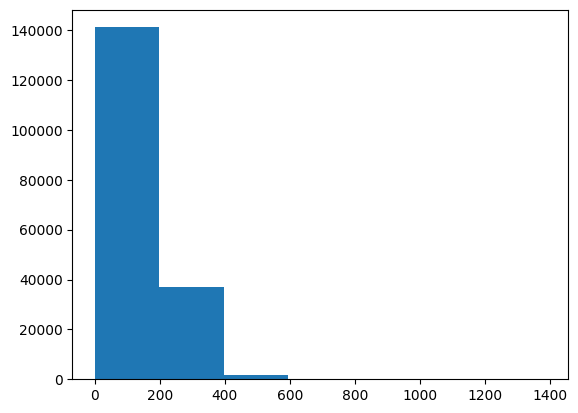

In [38]:
# Check the distribution of our sequences at a character-level
import matplotlib.pyplot as plt

plt.hist(char_lens,bins=7);

In [39]:
# Find what character length covers 95% of sequences
output_seq_char_len = int(np.percentile(char_lens,95))
output_seq_char_len

290

**Standardization vs Normalization**

---

## Standardization (Z-score scaling)

genui{"math_block_widget_always_prefetch_v2": {"content": "z = \frac{x - \mu}{\sigma}"}}

**Effect**

* Mean → 0
* Standard deviation → 1
* Data is centered and scaled but **not bounded**

**Properties**

* Preserves shape of distribution
* Handles outliers better than normalization (but still affected)
* Produces negative and positive values

**Use when**

* Data is roughly Gaussian
* Models assume centered data:

  * Logistic Regression
  * SVM
  * Linear Regression
  * Neural Networks (often preferred)

---

## Normalization (Min-Max scaling)

x' = \frac{x - x_{min}}{x_{max} - x_{min}}

**Effect**

* Scales values to a fixed range (usually **[0, 1]**)
* No centering, just rescaling

**Properties**

* Sensitive to outliers (they squash the rest)
* Preserves relative distances but compresses range

**Use when**

* You need bounded input:

  * Image data (0–255 → 0–1)
  * Neural networks with sigmoid/tanh
  * Distance-based models (KNN, K-means)

---

## Direct comparison

| Aspect       | Standardization | Normalization           |
| ------------ | --------------- | ----------------------- |
| Formula      | (x − μ) / σ     | (x − min) / (max − min) |
| Range        | Unbounded       | [0, 1] (or custom)      |
| Mean         | 0               | Not fixed               |
| Outliers     | Less sensitive  | Highly sensitive        |
| Distribution | Preserved shape | Distorted by extremes   |

---

## Key intuition

* Standardization = **shift + scale based on statistics**
* Normalization = **squeeze into a box**

---

## Practical rule

* General ML default → **standardization**
* Bounded inputs / pixel / distance models → **normalization**


In [40]:
# Get all keyboard characters
import string
alphabet = string.ascii_lowercase + string.digits + string.punctuation
alphabet # We didn't use uppercase because we already turned our texts into lower case while creating dictionary

'abcdefghijklmnopqrstuvwxyz0123456789!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [41]:
# Create char-level token vectorizer instance
NUM_CHAR_TOKENS = len(alphabet) + 2 # add 2 for space and OOV token (OOV = out of vocab, ['UNK'])
char_vectorizer = TextVectorization(max_tokens=NUM_CHAR_TOKENS,
                                    output_sequence_length=output_seq_char_len,
                                    output_mode='int',
                                    standardize="lower_and_strip_punctuation", # set standardize to "None" if you want to leave punctuation in
                                    split="whitespace",
                                    name="char_vectorizer")

In [42]:
# Adapt character vectorizer to training character
char_vectorizer.adapt(train_chars)

In [43]:
# Check character vocab stats
char_vocab = char_vectorizer.get_vocabulary()
print(f"Number of characters in vocab: {len(char_vocab)}")
print(f"5 most common Characters in vocab: {char_vocab[:5]}")
print(f"5 least common Characters in vocab: {char_vocab[-5:]}")

Number of characters in vocab: 28
5 most common Characters in vocab: ['', '[UNK]', np.str_('e'), np.str_('t'), np.str_('i')]
5 least common Characters in vocab: [np.str_('k'), np.str_('x'), np.str_('z'), np.str_('q'), np.str_('j')]


In [ ]:
# Test out our character vectorizer
random_train_chars = random.choice(train_chars)

print(f"Charified text:\n{random_train_chars}\n")
print(f"Length of random train chars: {len(random_train_chars)}")

vectorized_chars=char_vectorizer([random_train_chars])
print(f"\nVectorized chars:\n{vectorized_chars}")

<h1 style="color:red">lec 018:-Creating a character-level embedding layer with tf.keras.layers.Embedding</h1>

## Creating a character level embedding

**Masking vs cuDNN — Summary**

```text
cuDNN:
- GPU-optimized LSTM
- Very fast (2x–10x speedup)
- Requires strict right-padding mask

Masking:
- Ignores padded tokens
- Works with variable-length sequences
- Breaks cuDNN if mask is irregular
```

---

**Tradeoff**

```text
cuDNN + masking      → ❌ not compatible (error)
cuDNN without mask   → ✅ fastest
masking without cuDNN → slower
```

---

**In hybrid models (token + char)**

```text
Masks become irregular → cuDNN fails
```

---

**Best choice for performance**

```python
Embedding(..., mask_zero=False)
```

---

**Core idea**

```text
Hardware optimization (cuDNN) > logical optimization (masking)
```


In [44]:
# Create char embedding layer
char_embed = layers.Embedding(input_dim=len(char_vocab)+1, # Number of different characters
                              output_dim=25, # Number of dimensions for embedding
                              mask_zero = True, # remember if you set mask_zero = True you have to add 1 for masks in input_dim
                              name = "char_embed")

In [ ]:
# Test our character embedding layer
char_embed_example = char_embed(char_vectorizer([random_train_chars])) # remember to give single input string in list for consistency

print(f"Charified text:\n {random_train_chars}\n")
print(f"Embedded chars (after vectorizationa and embedding):\n {char_embed_example}\n")
print(f"Character embedding shape: {char_embed_example.shape}")

<h1 style="color:red">lec 019:-Model 3_ Building, fitting and evaluating a Conv1D model on character embeddings</h1>

### Building a Conv1D model to fit on character embeddings

In [ ]:
# Make Conv1D on chars only
inputs = layers.Input(shape=(1,),dtype="string")
char_vectors = char_vectorizer(inputs)
char_embeddings = char_embed(char_vectors)
x = layers.Conv1D(64, kernel_size=5, strides=1,padding="same", activation="relu")(char_embeddings)
x = layers.GlobalMaxPool1D()(x)

outputs = layers.Dense(num_classes, activation="softmax")(x)

model_3 = tf.keras.Model(inputs, outputs)

# Compile the model
model_3.compile(loss="categorical_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

In [ ]:
model_3.summary()

In [ ]:
# Creating our char level data to prefetch dataset for fast performance pipeline
train_char_dataset = tf.data.Dataset.from_tensor_slices((train_chars,train_labels_one_hot)).batch(32).prefetch(tf.data.AUTOTUNE)
val_char_dataset = tf.data.Dataset.from_tensor_slices((val_chars,val_labels_one_hot)).batch(32).prefetch(tf.data.AUTOTUNE)
test_char_dataset = tf.data.Dataset.from_tensor_slices((test_chars,test_labels_one_hot)).batch(32).prefetch(tf.data.AUTOTUNE)

In [ ]:
train_char_dataset

In [ ]:
# Fit the model on chars only
model_3_history = model_3.fit(train_char_dataset,
                              steps_per_epoch=int(0.1*len(train_char_dataset)),
                              epochs=3,
                              validation_data=val_char_dataset,
                              validation_steps=int(0.1*(len(val_char_dataset))),
                              callbacks=create_tensorboard_callback(SAVE_DIR,
                                                                    "model_3_char_embed_conv1D"))

In [ ]:
# Make prediction with character model only
model_3_pred_probs = model_3.predict(val_char_dataset)
model_3_pred_probs

In [ ]:
# Convert prediction probabilities to class labels
model_3_preds = tf.argmax(model_3_pred_probs, axis=1)
model_3_preds

In [ ]:
# Calculate results for Conv!D model chars only
model_3_results = calculate_results(y_true=val_labels_encoded,
                                    y_pred = model_3_preds)

model_3_results

In [ ]:
baseline_results

<h1 style="color:red">lec 020:-Discussing how we're going to build Model 4 (character + token embeddings)</h1>

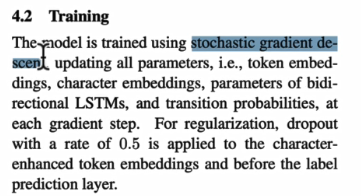

<h1 style="color:red">lec 021:-Model 4_ Building a multi-input model (hybrid token + character embeddings)</h1>

## Model 4: Combining pretrained token embeddings + charcaters embedding (hybrid embedding layer)

1. Create a token-level embedding model (similar to `model_1`)
2. Create a character-level model (similar to `model_3` with slight modifications)
3. Combine 1 & 2 with a concatenate (`layers.Concatenate`) **Only for functional API not sequential**
4. Build a series of output layers on top of 3 similar to Figure 1 and section 4.2 of https://arxiv.org/pdf/1612.05251.pdf
5. Construct a model which takes token and character-level sequences as input and produces sequence label probabilities as output.

**Masking vs cuDNN — Summary**

```text
cuDNN:
- GPU-optimized LSTM
- Very fast (2x–10x speedup)
- Requires strict right-padding mask

Masking:
- Ignores padded tokens
- Works with variable-length sequences
- Breaks cuDNN if mask is irregular
```

---

**Tradeoff**

```text
cuDNN + masking      → ❌ not compatible (error)
cuDNN without mask   → ✅ fastest
masking without cuDNN → slower
```

---

**In hybrid models (token + char)**

```text
Masks become irregular → cuDNN fails
```

---

**Best choice for performance**

```python
Embedding(..., mask_zero=False)
```

---

**Core idea**

```text
Hardware optimization (cuDNN) > logical optimization (masking)
```


In [53]:
# Create char embedding layer
char_embed_no_mask_for_hybrid = layers.Embedding(input_dim=len(char_vocab), # Number of different characters
                              output_dim=25, # Number of dimensions for embedding
                              mask_zero = False, # remember if you set mask_zero = True you have to add 1 for masks in input_dim also if you're doing things on GPU with concatenate layer hybrid model in LSTM set mask = False because minial computation tradeoff is better then use_cudnn = False tradeoff in bidirectional layer in LSTM(64,use_cudnn=False)
                              name = "char_embed")

In [54]:
# 1. Setup token inputs/model
token_inputs = layers.Input(shape=[],dtype='string', name = 'token_input')
token_embeddings = USELayer(trainable=False)(token_inputs)
token_outputs = layers.Dense(128, activation='relu')(token_embeddings)
token_model = tf.keras.Model(inputs=token_inputs,
                             outputs=token_outputs)

# 2. Setup char inputs/model
char_inputs = layers.Input(shape=(1,),dtype='string', name = 'char_input')
char_vectors = char_vectorizer(char_inputs)
char_embeddings = char_embed_no_mask_for_hybrid(char_vectors)
char_bi_lstm = layers.Bidirectional(layers.LSTM(24, # we will get 48 in dimension because it's bidirectional it doubles the units
                                                # return_sequences=True # set it to true when you want to build another LSTM layer below it
                                                ))(char_embeddings) # bi-LSTM shown in Figure 1 of https://arxiv.org/pdf/1612.05251.pdf
char_model = tf.keras.Model(inputs=char_inputs,
                            outputs=char_bi_lstm)

# 3. Concatenate token and char inputs (create hybrid token embedding)
token_char_concat = layers.Concatenate(name='token_char_hybrid')([token_model.output,
                                                                  char_model.output])

# 4. Create output layers- adding in dropout, discussed in section 4.2 of https://arxiv.org/pdf/1612.05251.pdf
combined_dropout = layers.Dropout(0.5)(token_char_concat) # to stop overfitting we do this for complex model so it generalize well
combined_dense = layers.Dense(128, activation='relu')(combined_dropout)
final_dropout = layers.Dropout(0.5)(combined_dense)
output_layer = layers.Dense(num_classes,activation = "softmax")(final_dropout)

# 5. Construct model with char and token inputs
model_4 = tf.keras.Model(inputs=[token_model.input, char_model.input],
                         outputs=output_layer,
                         name="model_4_token_and_char_embeddings")

In [55]:
# Get a summary of our model
model_4.summary()

Model: "model_4_token_and_char_embeddings"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ char_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_input         │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ char_vectorizer     │ (None, 290)       │          0 │ char_input[0][0]  │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ use_layer_2         │ (None, 512)       │          0 │ token_input[0][0] │
│ (USELayer)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ char_embed          │ (None, 290, 25)   │        700 │ char_vectorizer[… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 128)       │     65,664 │ use_layer_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 48)        │      9,600 │ char_embed[0][0]  │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_char_hybrid   │ (None, 176)       │          0 │ dense_5[0][0],    │
│ (Concatenate)       │                   │            │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 176)       │          0 │ token_char_hybri… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 128)       │     22,656 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 5)         │        645 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 99,265 (387.75 KB)

 Trainable params: 99,265 (387.75 KB)

 Non-trainable params: 0 (0.00 B)

<h1 style="color:red">lec 022:-Model 4_ Plotting and visually exploring different data inputs</h1>

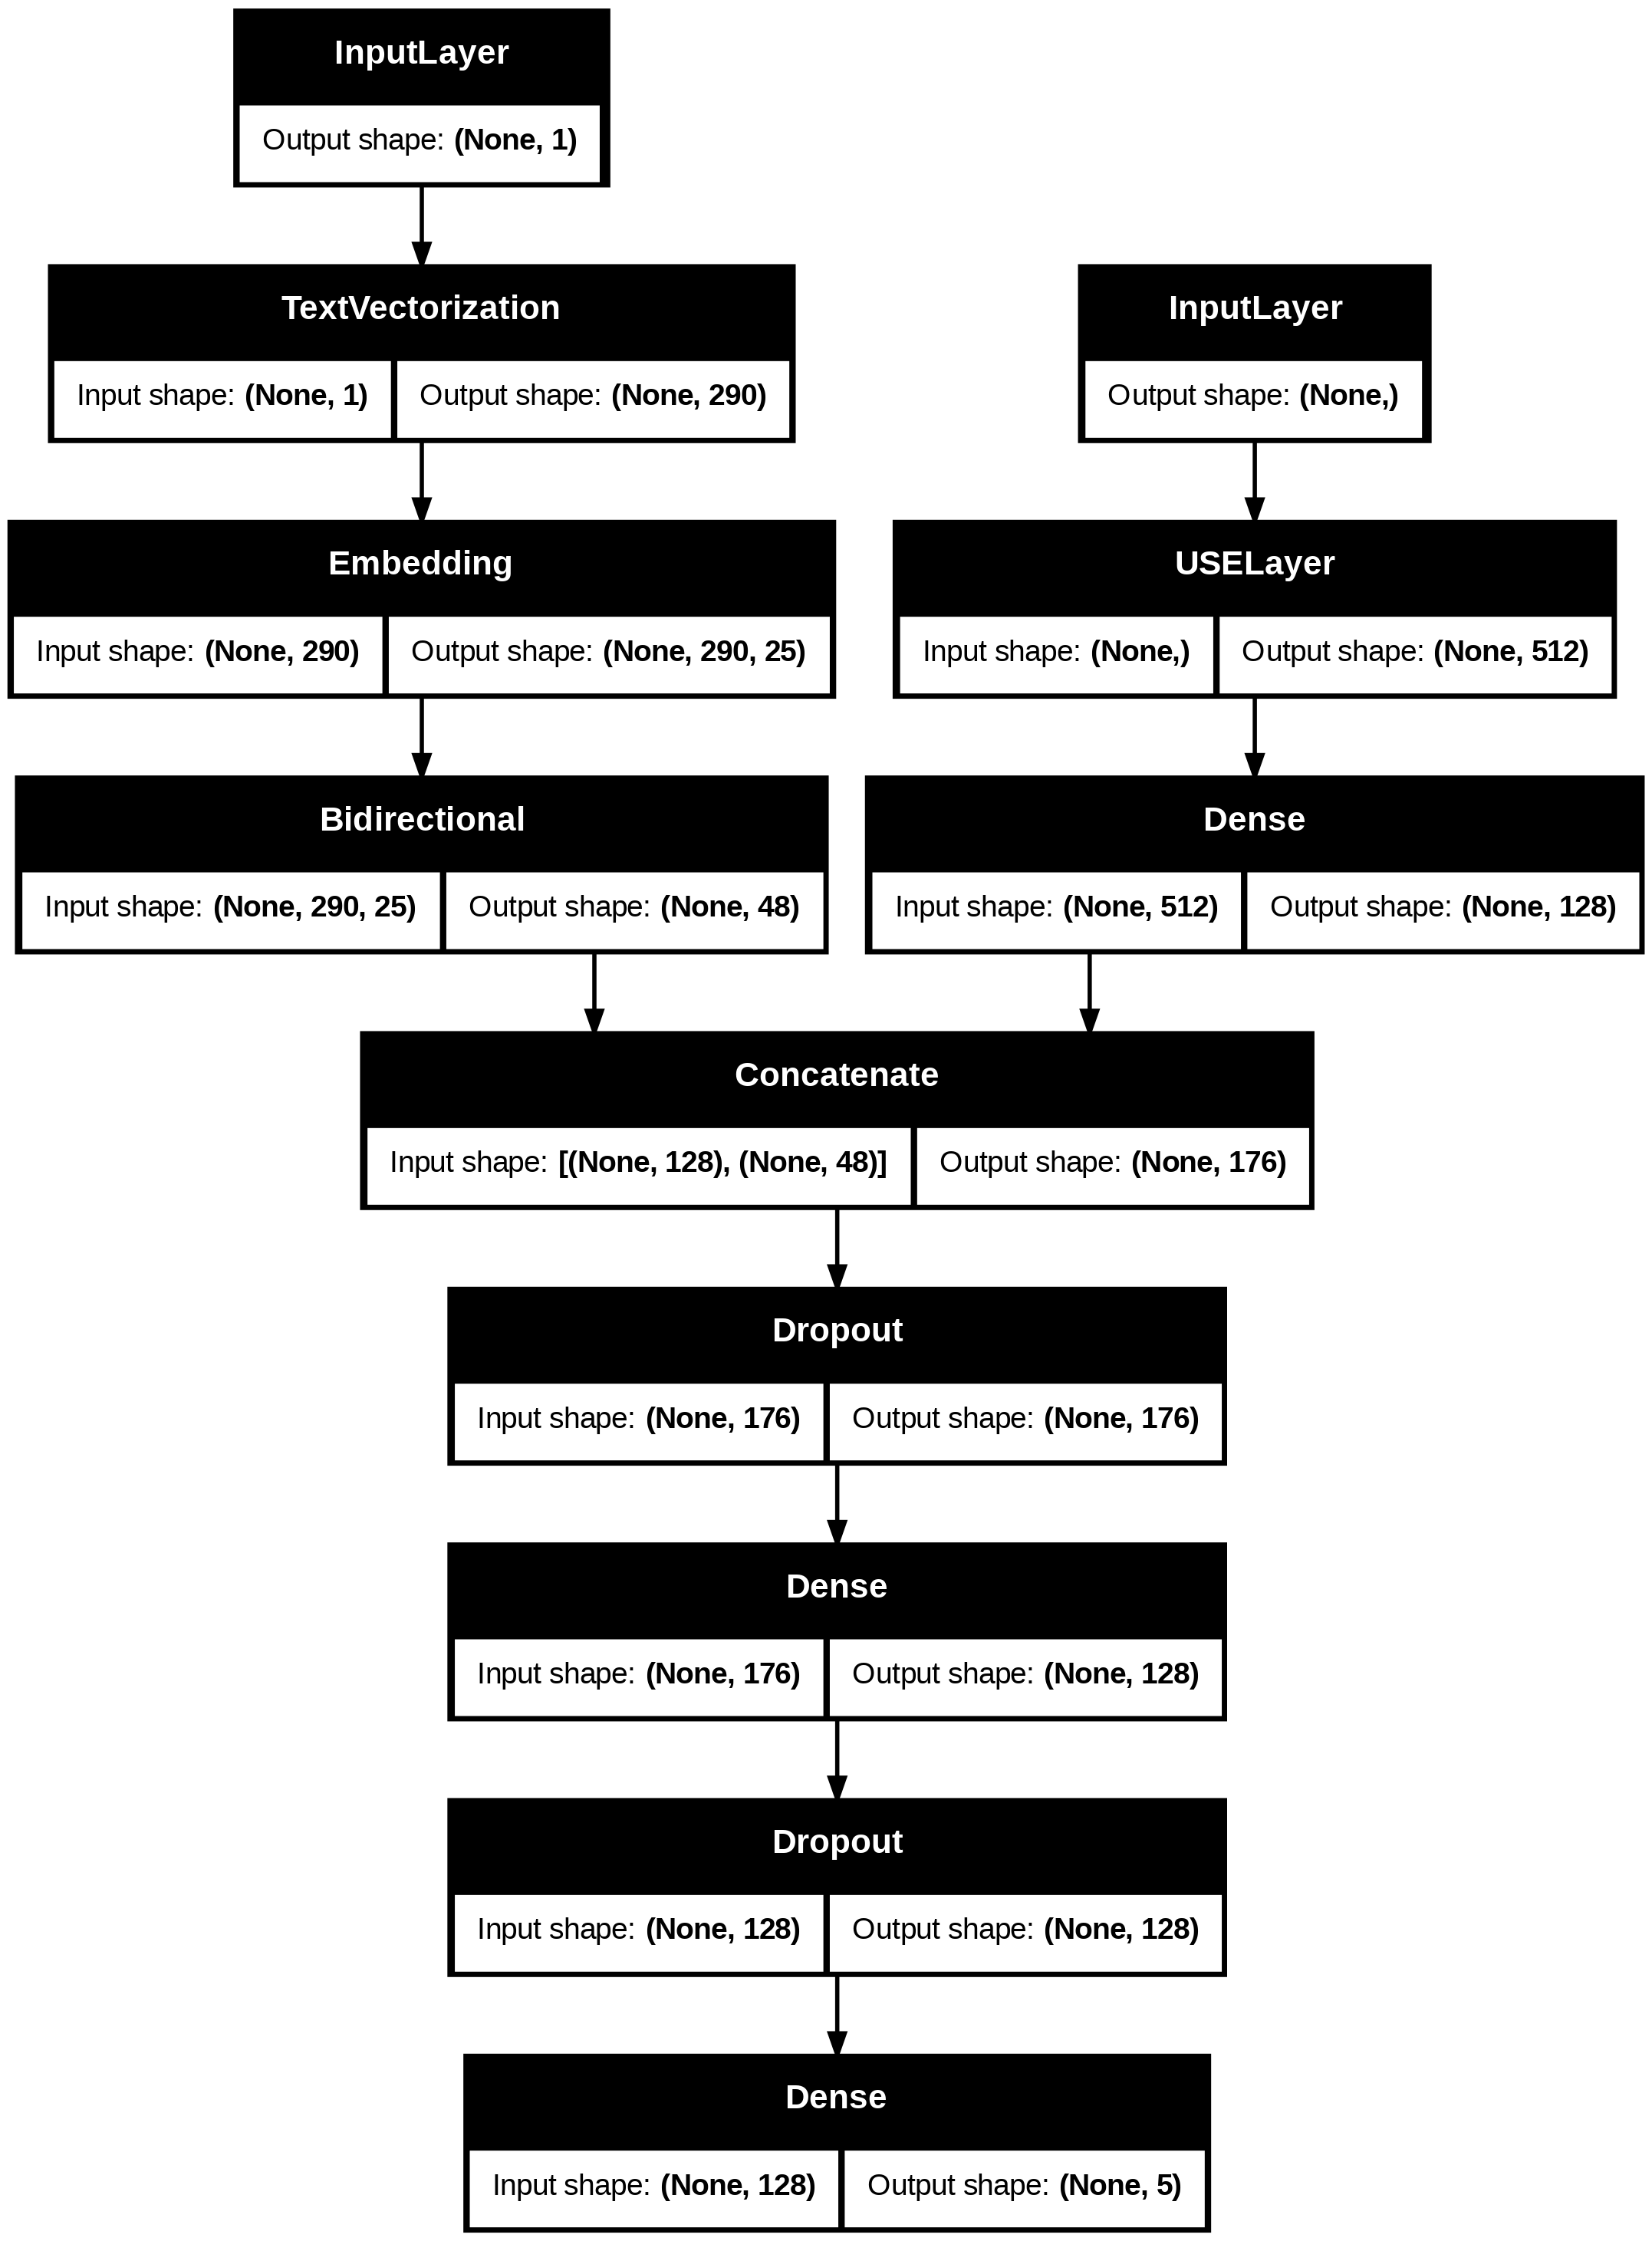

In [56]:
# Plot hybrid token and character model
from keras.utils import plot_model
plot_model(model_4,show_shapes=True)

>📖**Resources:** For different research paper on multimodel you can see and implement this: https://medium.com/airbnb-engineering/widetext-a-multimodal-deep-learning-framework-31ce2565880c

In [57]:
# Compile the token char model
model_4.compile(loss="categorical_crossentropy",
                optimizer=tf.keras.optimizers.Adam(), # section 4.2 of paper says they use SGD, you might want to try this
                metrics=['accuracy'])

<h1 style="color:red">lec 023:-Crafting multi-input fast loading tf.data datasets for Model 4</h1>

### Combining token and character data into a tf.data Dataset

>Rem:- order of inputs must be same as concatenate layer in our model

In [58]:
# Combine chars and tokens into a dataset
train_token_char_data = tf.data.Dataset.from_tensor_slices((train_sentences,train_chars)) # Make data
train_token_char_labels = tf.data.Dataset.from_tensor_slices(train_labels_one_hot) # make labels
train_token_char_dataset = tf.data.Dataset.zip((train_token_char_data,train_token_char_labels)) # combine existing datasets

# Prefetch and batch train data
train_token_char_dataset = train_token_char_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

> Above code in one line:-
```
train_token_char_dataset = tf.data.Dataset.from_tensor_slices(((train_sentences, train_chars), train_labels_one_hot)).batch(32).prefetch(tf.data.AUTOTUNE)
```

In [59]:
# Repeat the above steps for our validation and test data
val_token_char_dataset = tf.data.Dataset.from_tensor_slices(((val_sentences, val_chars), val_labels_one_hot)).batch(32).prefetch(tf.data.AUTOTUNE)
test_token_char_dataset = tf.data.Dataset.from_tensor_slices(((test_sentences, test_chars), test_labels_one_hot)).batch(32).prefetch(tf.data.AUTOTUNE)

In [60]:
# Check out our training char and token embedding dataset
train_token_char_dataset, val_token_char_dataset

(<_PrefetchDataset element_spec=((TensorSpec(shape=(None,), dtype=tf.string, name=None), TensorSpec(shape=(None,), dtype=tf.string, name=None)), TensorSpec(shape=(None, 5), dtype=tf.float64, name=None))>,
 <_PrefetchDataset element_spec=((TensorSpec(shape=(None,), dtype=tf.string, name=None), TensorSpec(shape=(None,), dtype=tf.string, name=None)), TensorSpec(shape=(None, 5), dtype=tf.float64, name=None))>)

<h1 style="color:red">lec 024:-Model 4_ Building, fitting and evaluating a hybrid embedding model</h1>

### Fitting a model on token and character-level sequences

In [61]:
# Fit the model on tokens and chars
history_model_4 = model_4.fit(train_token_char_dataset,
                              steps_per_epoch=int(0.1*len(train_token_char_dataset)),
                              epochs=3,
                              validation_data=val_token_char_dataset,
                              validation_steps=int(0.1*(len(val_token_char_dataset))),
                              callbacks=create_tensorboard_callback(SAVE_DIR,
                                                                    "model_4_hybrid_embedding_model"))

Saving TensorBoard log files to: model_logs/model_4_hybrid_embedding_model/20260329-051011
Epoch 1/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 30s 42ms/step - accuracy: 0.6047 - loss: 0.9911 - val_accuracy: 0.6961 - val_loss: 0.7860
Epoch 2/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 41s 73ms/step - accuracy: 0.6883 - loss: 0.8069 - val_accuracy: 0.7271 - val_loss: 0.7238
Epoch 3/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 24s 43ms/step - accuracy: 0.7003 - loss: 0.7846 - val_accuracy: 0.7311 - val_loss: 0.6969


In [62]:
# Evaluate on the whole validation dataset
model_4.evaluate(val_token_char_dataset)

945/945 ━━━━━━━━━━━━━━━━━━━━ 21s 23ms/step - accuracy: 0.7300 - loss: 0.7018


[0.7017701864242554, 0.7300079464912415]

In [63]:
# Make predictions using the token-character model hybrid
model_4_pred_probs = model_4.predict(val_token_char_dataset)
model_4_pred_probs

945/945 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step


array([[3.82330745e-01, 4.06113505e-01, 3.89836566e-03, 1.97482616e-01,
        1.01747876e-02],
       [3.51455361e-01, 4.63654250e-01, 2.46748095e-03, 1.79373994e-01,
        3.04894079e-03],
       [3.05536836e-01, 1.68026701e-01, 5.87787069e-02, 4.15458649e-01,
        5.21990620e-02],
       ...,
       [3.16773716e-04, 7.50946626e-03, 3.77945378e-02, 1.15533316e-04,
        9.54263747e-01],
       [7.27151847e-03, 5.89322969e-02, 2.17690423e-01, 2.95129395e-03,
        7.13154495e-01],
       [3.26204449e-01, 3.58859748e-01, 2.30269060e-01, 3.57614197e-02,
        4.89053391e-02]], dtype=float32)

In [64]:
# Format pred probs into pred labels
model_4_preds = tf.argmax(model_4_pred_probs, axis=1)
model_4_preds

<tf.Tensor: shape=(30212,), dtype=int64, numpy=array([1, 1, 3, ..., 4, 4, 1])>

In [65]:
# get results of token-char-hybrid model
model_4_results = calculate_results(y_true=val_labels_encoded,
                                    y_pred=model_4_preds)

model_4_results

{'accuracy': 73.00079438633655,
 'precision': 0.7293680260128934,
 'recall': 0.7300079438633655,
 'f1': 0.726385407957773}

<h1 style="color:red">lec 025:-Model 5_ Adding positional embeddings via feature engineering (overview)</h1>

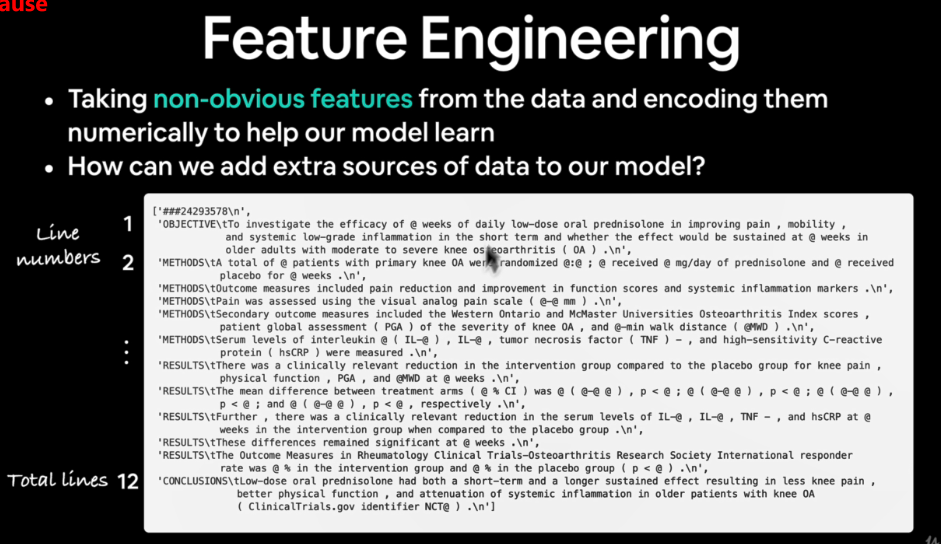

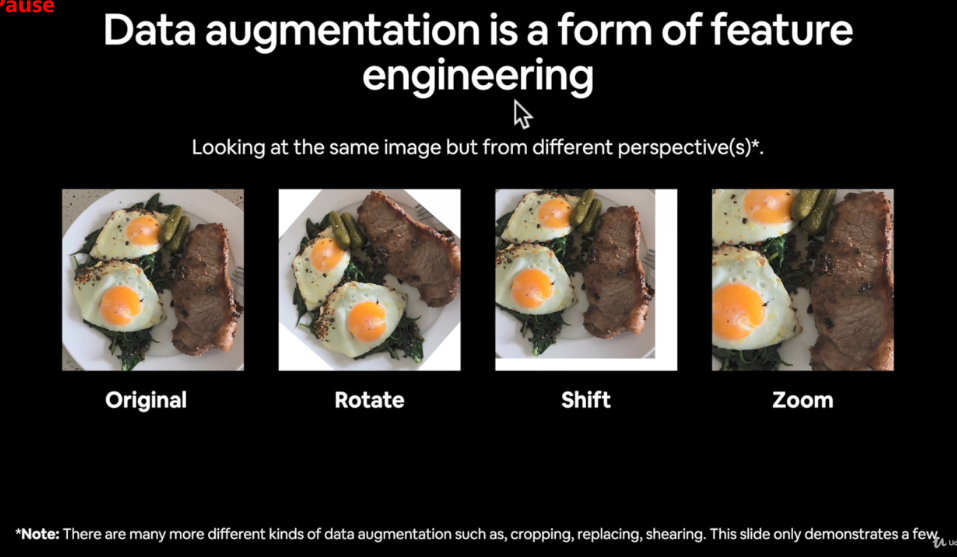

<h1 style="color:red">lec 026:-Encoding the line number feature to used with Model 5</h1>

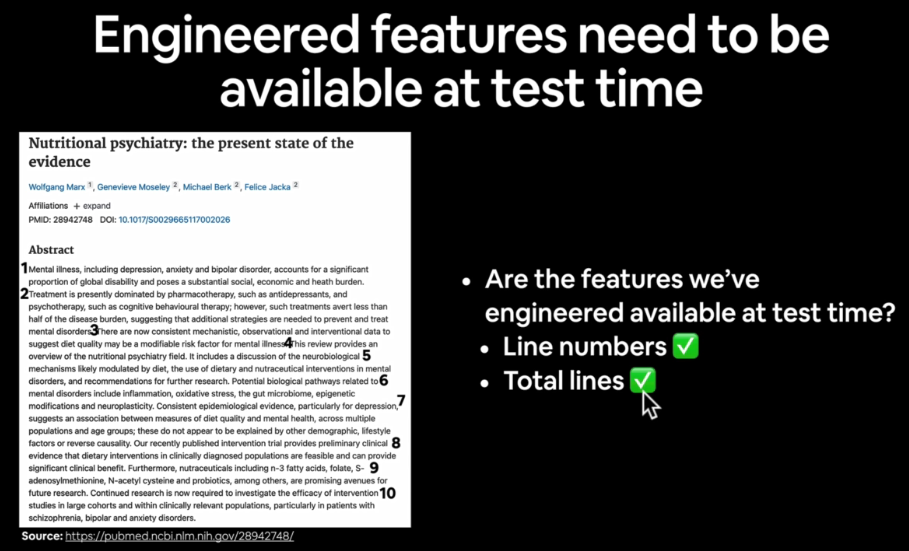

## Model 5: Transfer learning with pretrained token embeddings + character embeddings + positional embeddings

In [66]:
train_df.head()

,target,text,line_number,total_lines
0,OBJECTIVE,to investigate the efficacy of @ weeks of dail...,0,11
1,METHODS,a total of @ patients with primary knee oa wer...,1,11
2,METHODS,outcome measures included pain reduction and i...,2,11
3,METHODS,pain was assessed using the visual analog pain...,3,11
4,METHODS,secondary outcome measures included the wester...,4,11


>🔑**Note:** Any engineered feature used to train a model need to be available at test time. In our case, line numbers and total lines are available.

### Create positional embeddings

In [67]:
# How many different line numbers are there?
train_df["line_number"].value_counts() # We want line numbers to do one hot encoding but we don't want our one hot encoding to be very long

,count
line_number,
0,15000
1,15000
2,15000
3,15000
4,14992
5,14949
6,14758
7,14279
8,13346


<Axes: ylabel='Frequency'>

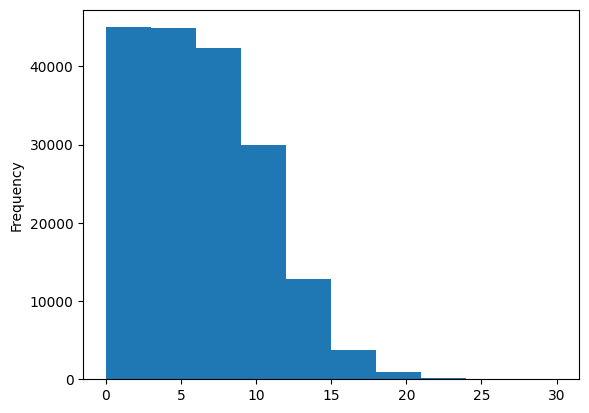

In [68]:
# Check the distribution of "line number" column
train_df.line_number.plot.hist()

> Note:- we're doing one hot encoding instead of label encoding (integers) because we don't want our model to think line number is 2 is 2 times larger than line number 1.

In [69]:
# Use TensorFlow to create one-hot-encoded tensors of our "line_number" column
train_line_numbers_one_hot = tf.one_hot(train_df["line_number"].to_numpy(),depth=15)
val_line_numbers_one_hot = tf.one_hot(val_df["line_number"].to_numpy(),depth=15)
test_line_numbers_one_hot = tf.one_hot(test_df["line_number"].to_numpy(),depth=15)
train_line_numbers_one_hot[:10], train_line_numbers_one_hot.shape

(<tf.Tensor: shape=(10, 15), dtype=float32, numpy=
 array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]],
       dtype=float32)>,
 TensorShape([180040, 15]))

<h1 style="color:red">lec 027:-Encoding the total lines feature to be used with Model 5</h1>

In [70]:
train_df.head()

,target,text,line_number,total_lines
0,OBJECTIVE,to investigate the efficacy of @ weeks of dail...,0,11
1,METHODS,a total of @ patients with primary knee oa wer...,1,11
2,METHODS,outcome measures included pain reduction and i...,2,11
3,METHODS,pain was assessed using the visual analog pain...,3,11
4,METHODS,secondary outcome measures included the wester...,4,11


Now we've encoded our line numbers feature, let's do the same for our total lines feature...

In [71]:
# How many different numbers of lines are there?
train_df.total_lines.value_counts()

,count
total_lines,
11,24468
10,23639
12,22113
9,19400
13,18438
14,14610
8,12285
15,10768
7,7464


<Axes: ylabel='Frequency'>

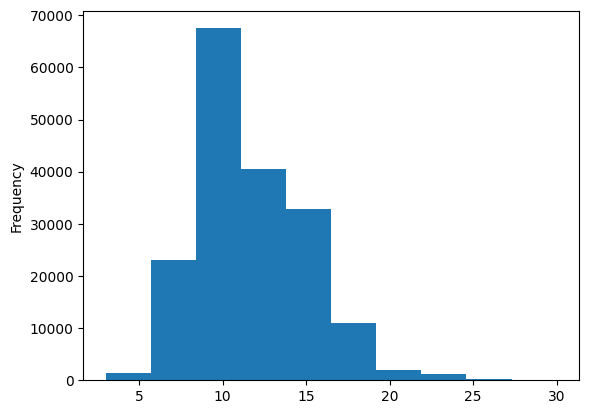

In [72]:
# Check the distributions of total lines
train_df.total_lines.plot.hist()

In [73]:
# Check the coverage of a "total_lines" value of 20
np.percentile(train_df.total_lines,[2,98])

array([ 6., 20.])

Clipping destroys information. You need **binning**, not clipping.

---

## Goal

Keep:

* values < 6
* values 6–20
* values > 20

---

## Solution: create 3 regions

```text
<6 | 6–20 | >20
```

Total classes =

```text
1 (below) + 15 (6–20) + 1 (above) = 17
```

---

## Implementation

```python id="r4z3b7"
lower, upper = 6, 20

values = train_df.total_lines.values

# create indices
indices = np.where(
    values < lower, 0,                                  # bucket 0
    np.where(
        values > upper, upper - lower + 1,              # bucket 16
        values - lower + 1                              # buckets 1–15
    )
)

one_hot = tf.one_hot(indices, depth=(upper - lower + 3))
```

---

## Mapping

```text
value < 6     → index 0
value = 6     → index 1
value = 7     → index 2
...
value = 20    → index 15
value > 20    → index 16
```

---

## Example

```text
values = [3, 6, 10, 20, 25]

indices = [0, 1, 5, 15, 16]
```

---

## Key idea

```text
Don’t clip → bucket extremes separately
```

---

## Result

* No data loss
* Model sees:

  * “too small”
  * “normal range”
  * “too large”


In [74]:
# Use TensorFlow to create one-hot-encode tensors of our "total_lines" feature
train_total_lines_one_hot = tf.one_hot(train_df["total_lines"].to_numpy(),depth=20)
val_total_lines_one_hot = tf.one_hot(val_df["total_lines"].to_numpy(),depth=20)
test_total_lines_one_hot = tf.one_hot(test_df["total_lines"].to_numpy(),depth=20)
train_total_lines_one_hot.shape, train_total_lines_one_hot[:10]

(TensorShape([180040, 20]),
 <tf.Tensor: shape=(10, 20), dtype=float32, numpy=
 array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0

<h1 style="color:red">lec 028:-Model 5_ Building the foundations of a tribrid embedding model</h1>

### Building a tribrid embedding model

1. Create a token-level model
2. Create a character-level model
3. Create a model for the "line_number" feature
4. Create a model for the "total_lines" feature
5. Combine the outputs of 1 & 2 using tf.keras.layers.Concatenate
6. Combine the outputs of 3,4,5 using tf.keras.layers.Concatenate
7. Create an output layer to accept the tribried embedding and output label probabilities
8. Combine the inputs of 1, 2, 3, 4 and output of tf.keras.Model

In [124]:
import tensorflow as tf
from tensorflow.keras import layers

tf.keras.backend.clear_session()

# 1. Token inputs
token_inputs_m5 = layers.Input(shape=[], dtype=tf.string, name="m5_token_inputs")
token_embeddings_m5 = USELayer()(token_inputs_m5)
token_outputs_m5 = layers.Dense(128, activation="relu", name="m5_token_dense")(token_embeddings_m5)
token_model_m5 = tf.keras.Model(inputs=token_inputs_m5,
                               outputs=token_outputs_m5,
                               name="m5_token_model")

# 2. Char inputs
char_inputs_m5 = layers.Input(shape=(1,), dtype=tf.string, name="m5_char_inputs")
char_vectors_m5 = char_vectorizer(char_inputs_m5)
char_embeddings_m5 = char_embed_no_mask_for_hybrid(char_vectors_m5)
char_bilstm_m5 = layers.Bidirectional(
    layers.LSTM(24),
    name="m5_char_bilstm"
)(char_embeddings_m5)

char_model_m5 = tf.keras.Model(inputs=char_inputs_m5,
                              outputs=char_bilstm_m5,
                              name="m5_char_model")

# 3. Line number input
line_inputs_m5 = layers.Input(shape=(15,), dtype=tf.float32, name="m5_line_inputs")
line_dense_m5 = layers.Dense(32, activation="relu", name="m5_line_dense")(line_inputs_m5)
line_model_m5 = tf.keras.Model(inputs=line_inputs_m5,
                              outputs=line_dense_m5,
                              name="m5_line_model")

# 4. Total lines input
total_inputs_m5 = layers.Input(shape=(20,), dtype=tf.float32, name="m5_total_inputs")
total_dense_m5 = layers.Dense(32, activation="relu", name="m5_total_dense")(total_inputs_m5)
total_model_m5 = tf.keras.Model(inputs=total_inputs_m5,
                               outputs=total_dense_m5,
                               name="m5_total_model")

# 5. Token + Char combine
combined_m5 = layers.Concatenate(name="m5_token_char_concat")([
    token_model_m5.output,
    char_model_m5.output
])

z_m5 = layers.Dense(256, activation="relu", name="m5_dense_256")(combined_m5)
z_m5 = layers.Dropout(0.5, name="m5_dropout")(z_m5)

# 6. Add positional embeddings
tribrid_m5 = layers.Concatenate(name="m5_tribrid_concat")([
    line_model_m5.output,
    total_model_m5.output,
    z_m5
])

# 7. Output
outputs_m5 = layers.Dense(num_classes, activation="softmax", name="m5_output")(tribrid_m5)

# 8. Final model
model_5 = tf.keras.Model(
    inputs=[
        line_model_m5.input,
        total_model_m5.input,
        token_model_m5.input,
        char_model_m5.input
    ],
    outputs=outputs_m5,
    name="m5_tribrid_model"
)


In [125]:
# Get a summary of our tribrid embedding model
model_5.summary()

Model: "m5_tribrid_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ m5_char_inputs      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ m5_token_inputs     │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ char_vectorizer     │ (None, 290)       │          0 │ m5_char_inputs[0… │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ use_layer           │ (None, 512)       │          0 │ m5_token_inputs[… │
│ (USELayer)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ char_embed          │ (None, 290, 25)   │        700 │ char_vectorizer[… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ m5_token_dense      │ (None, 128)       │     65,664 │ use_layer[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ m5_char_bilstm      │ (None, 48)        │      9,600 │ char_embed[9][0]  │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ m5_token_char_conc… │ (None, 176)       │          0 │ m5_token_dense[0… │
│ (Concatenate)       │                   │            │ m5_char_bilstm[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ m5_line_inputs      │ (None, 15)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ m5_total_inputs     │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ m5_dense_256        │ (None, 256)       │     45,312 │ m5_token_char_co… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ m5_line_dense       │ (None, 32)        │        512 │ m5_line_inputs[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ m5_total_dense      │ (None, 32)        │        672 │ m5_total_inputs[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ m5_dropout          │ (None, 256)       │          0 │ m5_dense_256[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ m5_tribrid_concat   │ (None, 320)       │          0 │ m5_line_dense[0]… │
│ (Concatenate)       │                   │            │ m5_total_dense[0… │
│                     │                   │            │ m5_dropout[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ m5_output (Dense)   │ (None, 5)         │      1,605 │ m5_tribrid_conca… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 124,065 (484.63 KB)

 Trainable params: 124,065 (484.63 KB)

 Non-trainable params: 0 (0.00 B)

<h1 style="color:red">lec 030:-Visually inspecting the architecture of our tribrid embedding model</h1>

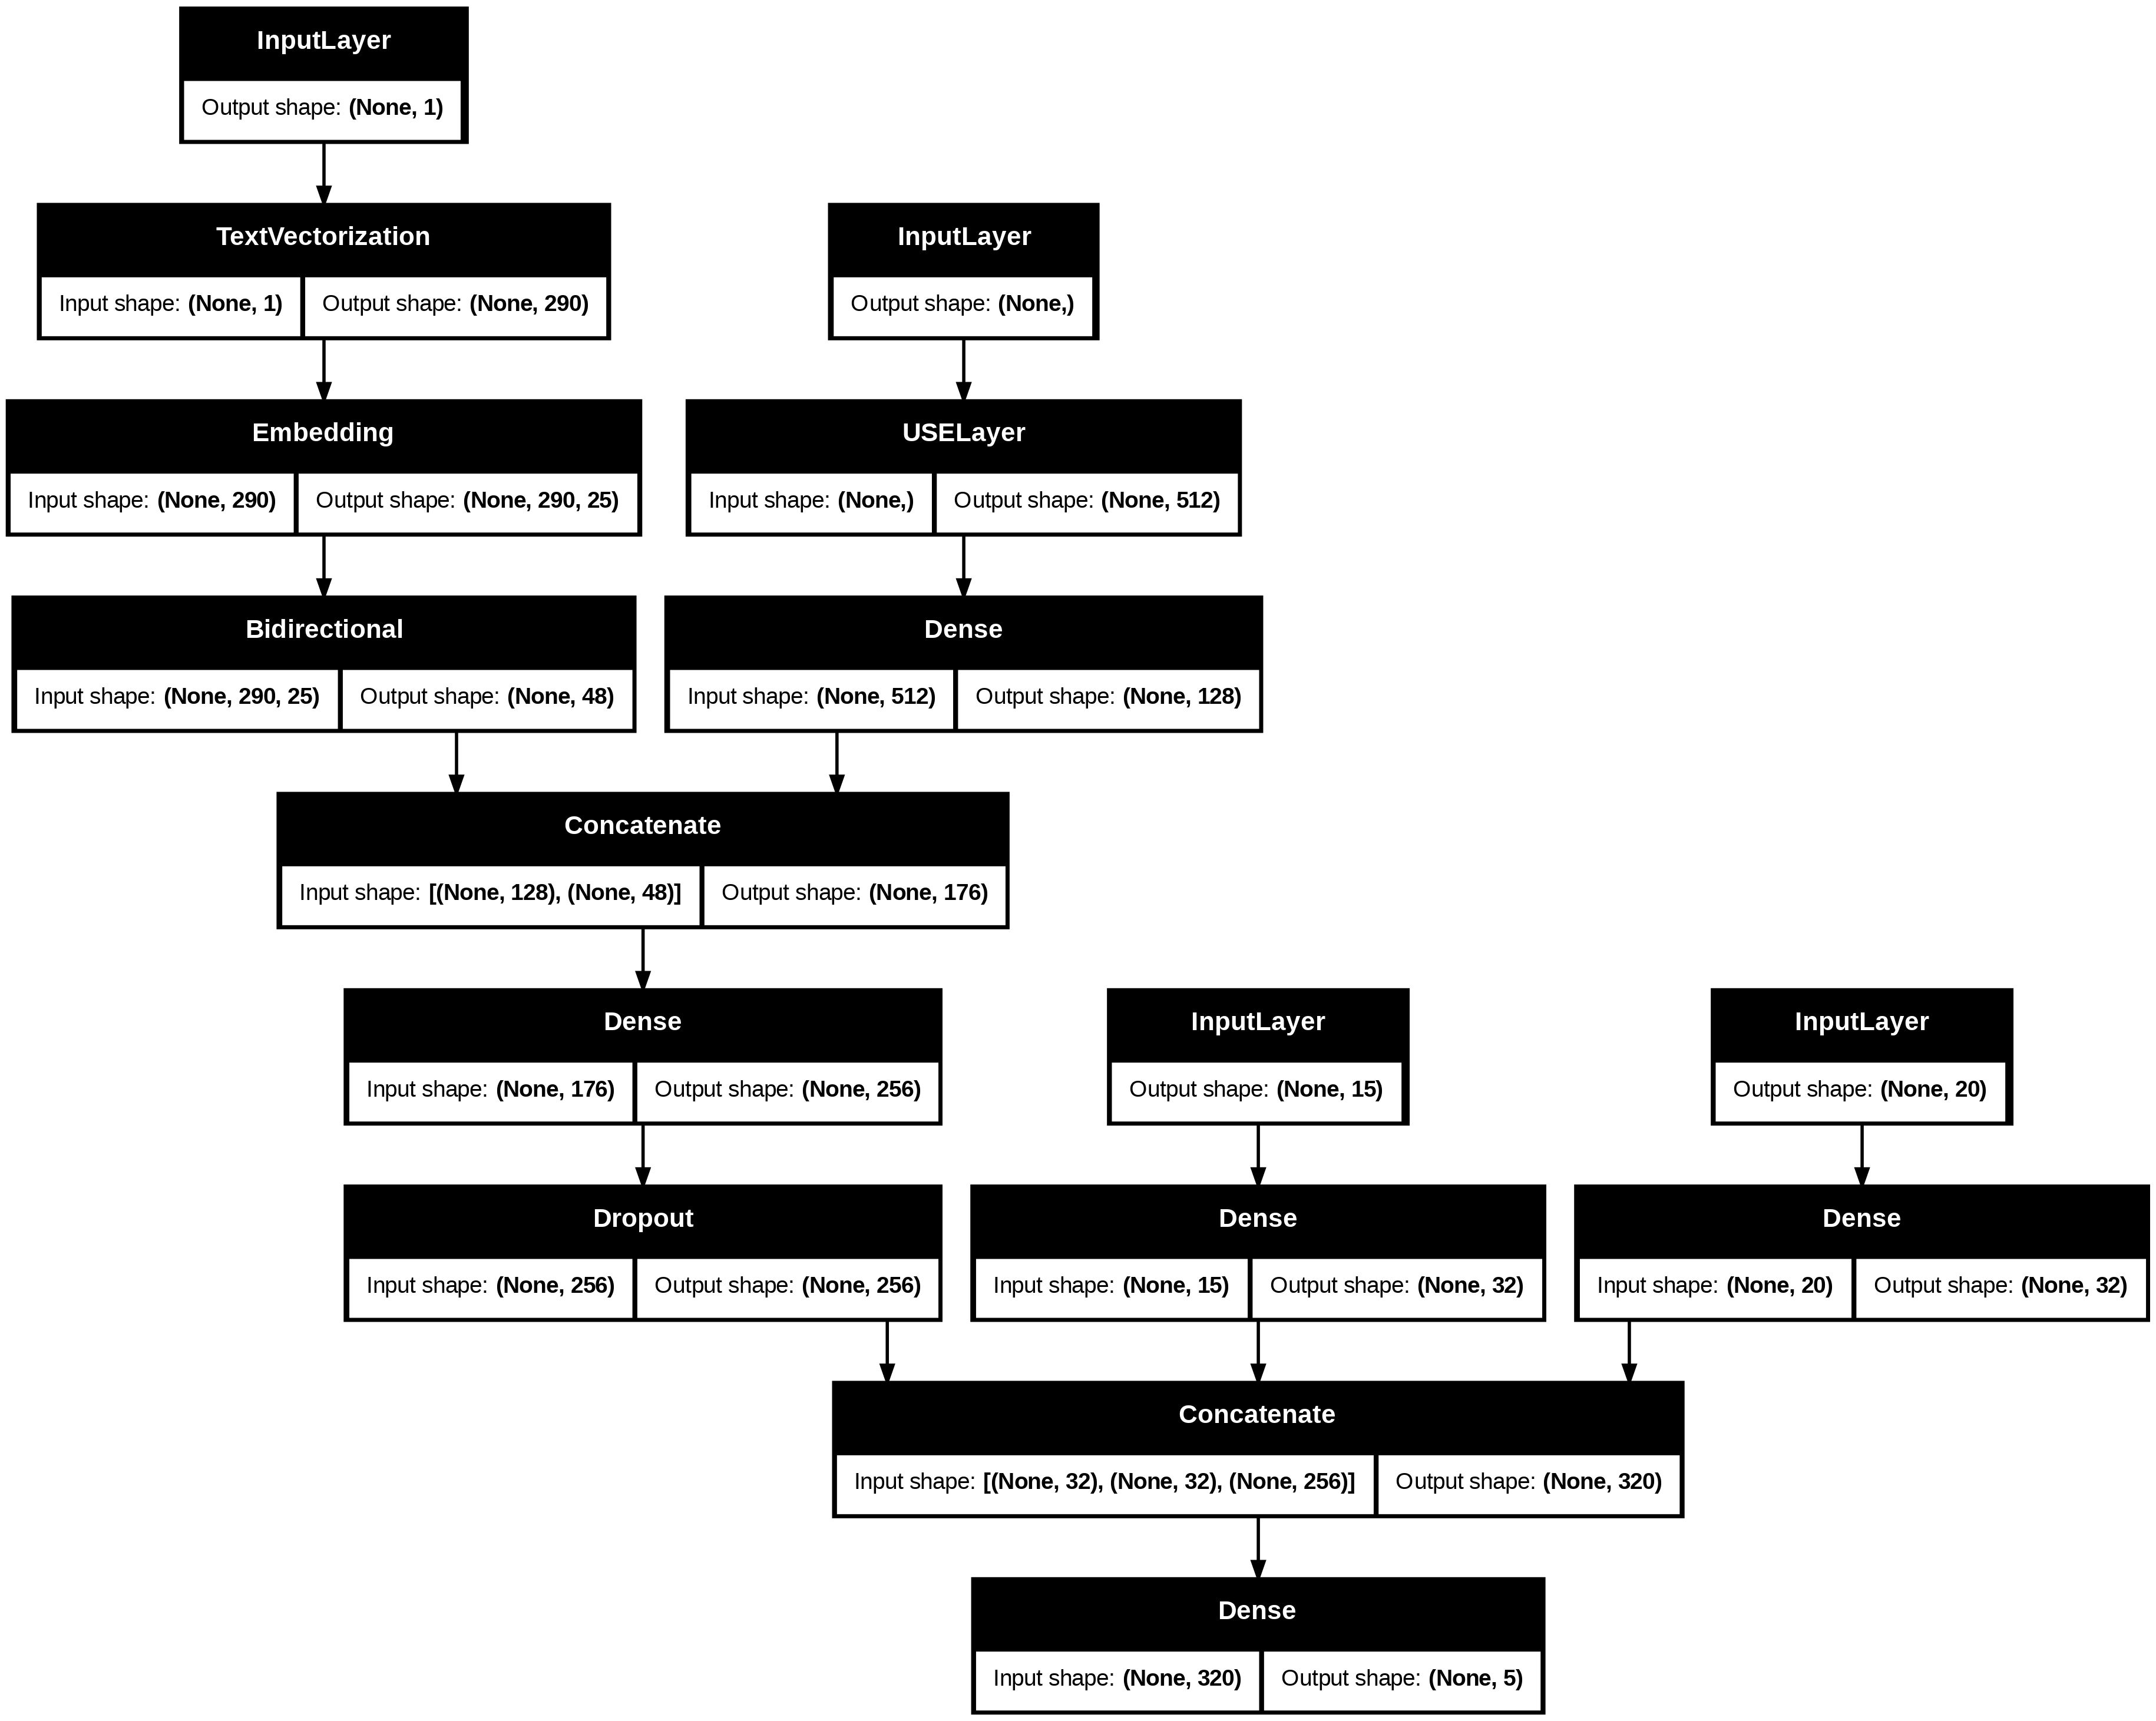

In [126]:
# Plot model_5 to explore it visually...
from tensorflow.keras.utils import plot_model
tf.keras.utils.plot_model(model_5,show_shapes=True)

> Label smoothing: helps to prevent overfitting


What is label smoothing?

for example if our model gets too confident on a single class (e.g. its prediction probability is really high), it may get stuck on that class and not consider other classes...

Really confident: `[0.0, 0.0, 1.0, 0.0, 0.0]`

What label smoothing does is it assigns some of the value from the highest pred prob to other classes, in turn, hopefully improving generalization: `[0.05, 0.05, 0.8, 0.05, 0.05]`

> 📖**Resource:** for more on label smoothing, see this blog post from PyImageSearch: https://pyimagesearch.com/2019/12/30/label-smoothing-with-keras-tensorflow-and-deep-learning/

In [127]:
# Compile token, char and positional embedding model
model_5.compile(loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.2), # helps to prevent overfitting
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])


#### hehe


##### Best practice (robust)

Use dictionary:

```python
train_dataset = tf.data.Dataset.from_tensor_slices((
    {
        "line": train_line_numbers_one_hot,
        "total": train_total_lines_one_hot,
        "token": train_sentences,
        "char": train_chars
    },
    train_labels_one_hot
))
```

Then model:

```python
Model(inputs={
    "line": line_input,
    "total": total_input,
    "token": token_input,
    "char": char_input
})
```

---

## Why this matters

```text id="mt13fs"
Keras matches inputs POSITIONALLY by default
```

---

## Bottom line

```text id="7bhb2j"
Your dataset is correct
Just ensure input ordering matches model exactly
```


### Create tribrid embedding datasets using tf.data

In [128]:
# Create training and validation datasets (with all kinds of input data)
train_char_token_pos_dataset = tf.data.Dataset.from_tensor_slices(((train_line_numbers_one_hot,
                                                                train_total_lines_one_hot,
                                                                train_sentences,
                                                                train_chars),train_labels_one_hot)).batch(32).prefetch(tf.data.AUTOTUNE)
# validation dataset
val_char_token_pos_dataset = tf.data.Dataset.from_tensor_slices(((val_line_numbers_one_hot,
                                                                val_total_lines_one_hot,
                                                                val_sentences,
                                                                val_chars),val_labels_one_hot)).batch(32).prefetch(tf.data.AUTOTUNE)

# test dataset
test_char_token_pos_dataset = tf.data.Dataset.from_tensor_slices(((test_line_numbers_one_hot,
                                                                test_total_lines_one_hot,
                                                                test_sentences,
                                                                test_chars),test_labels_one_hot)).batch(32).prefetch(tf.data.AUTOTUNE)

In [129]:
# Check input shape
train_char_token_pos_dataset.element_spec

((TensorSpec(shape=(None, 15), dtype=tf.float32, name=None),
  TensorSpec(shape=(None, 20), dtype=tf.float32, name=None),
  TensorSpec(shape=(None,), dtype=tf.string, name=None),
  TensorSpec(shape=(None,), dtype=tf.string, name=None)),
 TensorSpec(shape=(None, 5), dtype=tf.float64, name=None))

In [130]:
train_char_token_pos_dataset

<_PrefetchDataset element_spec=((TensorSpec(shape=(None, 15), dtype=tf.float32, name=None), TensorSpec(shape=(None, 20), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.string, name=None), TensorSpec(shape=(None,), dtype=tf.string, name=None)), TensorSpec(shape=(None, 5), dtype=tf.float64, name=None))>

### Fitting, evaluating and making predictions with our tribrid model

In [131]:
# Fit our tribrid embedding model
history_model_5 = model_5.fit(train_char_token_pos_dataset,
                              steps_per_epoch=int(0.1*len(train_char_token_pos_dataset)),
                              validation_data=val_char_token_pos_dataset,
                              validation_steps=int(0.1*len(val_char_token_pos_dataset)),
                              epochs=3)

Epoch 1/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 29s 43ms/step - accuracy: 0.7241 - loss: 1.0951 - val_accuracy: 0.8012 - val_loss: 0.9865
Epoch 2/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 49s 88ms/step - accuracy: 0.8146 - loss: 0.9692 - val_accuracy: 0.8245 - val_loss: 0.9547
Epoch 3/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 42s 74ms/step - accuracy: 0.8221 - loss: 0.9520 - val_accuracy: 0.8248 - val_loss: 0.9412


In [132]:
# Make predictions with char token model
model_5_pred_probs = model_5.predict(val_char_token_pos_dataset,verbose=1)
model_5_pred_probs[:10]

945/945 ━━━━━━━━━━━━━━━━━━━━ 46s 48ms/step


array([[0.47994065, 0.11083404, 0.01135278, 0.37995842, 0.01791413],
       [0.5531941 , 0.09273755, 0.04864054, 0.29373547, 0.01169228],
       [0.3120418 , 0.10414538, 0.12912998, 0.3921318 , 0.06255102],
       [0.03722205, 0.05605438, 0.73932856, 0.03798269, 0.12941238],
       [0.0673721 , 0.0665814 , 0.59365034, 0.05826188, 0.21413425],
       [0.01367071, 0.04091201, 0.25221404, 0.02120704, 0.67199624],
       [0.01796588, 0.05109164, 0.20952336, 0.02417021, 0.69724894],
       [0.01757564, 0.07840357, 0.16853951, 0.02348809, 0.7119932 ],
       [0.01704412, 0.0548795 , 0.03665   , 0.02803904, 0.8633874 ],
       [0.04604167, 0.734383  , 0.02802235, 0.04393217, 0.14762084]],
      dtype=float32)

In [133]:
# Convert pred probs to pred labels
model_5_preds = tf.argmax(model_5_pred_probs,axis=1)
model_5_preds[:10]

<tf.Tensor: shape=(10,), dtype=int64, numpy=array([0, 0, 3, 2, 2, 4, 4, 4, 4, 1])>

In [135]:
# Calculate results of char token pos model
model_5_results = calculate_results(y_true=val_labels_encoded,
                                    y_pred=model_5_preds)

model_5_results

{'accuracy': 82.92069376406725,
 'precision': 0.8280467114242507,
 'recall': 0.8292069376406725,
 'f1': 0.8283436097785153}

<h1 style="color:red">lec 033:-Comparing the performance of all of our modelling experiments</h1>

In [136]:
# Run this cell for direct results we gain, we can use this data without training the model next time

model_1_results = {'accuracy': 78.30994306897921,
 'precision': 0.7795707979763848,
 'recall': 0.7830994306897922,
 'f1': 0.7808049408223194}

baseline_results = {'accuracy': 72.1832384482987,
 'precision': 0.7186466952323352,
 'recall': 0.7218323844829869,
 'f1': 0.6989250353450294}

model_2_results = {'accuracy': 71.36568251026083,
 'precision': 0.7141154400849147,
 'recall': 0.7136568251026082,
 'f1': 0.7110898400947387}

model_3_results ={'accuracy': 69.36568251026083,
 'precision': 0.6741154400849147,
 'recall': 0.6836568251026082,
 'f1': 0.6710898400947387}

model_4_results = {'accuracy': 73.00079438633655,
 'precision': 0.7293680260128934,
 'recall': 0.7300079438633655,
 'f1': 0.726385407957773}

model_5_results = {'accuracy': 82.92069376406725,
 'precision': 0.8280467114242507,
 'recall': 0.8292069376406725,
 'f1': 0.8283436097785153}

## Compare model results

In [138]:
# Combine model results into a dataframe
all_model_results = pd.DataFrame({"model_0_baseline":baseline_results,
                                  "model_1_custom_token_embedding":model_1_results,
                                  "model_2_pretrained_token_embedding":model_2_results,
                                  "model_3_custom_char_embedding":model_3_results,
                                  "model_4_hybrid_char_token_embedding":model_4_results,
                                  "model_5_pos_char_token_embedding":model_5_results})
all_model_results = all_model_results.T
all_model_results

,accuracy,precision,recall,f1
model_0_baseline,72.183238,0.718647,0.721832,0.698925
model_1_custom_token_embedding,78.309943,0.779571,0.783099,0.780805
model_2_pretrained_token_embedding,71.365683,0.714115,0.713657,0.711090
model_3_custom_char_embedding,69.365683,0.674115,0.683657,0.671090
model_4_hybrid_char_token_embedding,73.000794,0.729368,0.730008,0.726385
model_5_pos_char_token_embedding,82.920694,0.828047,0.829207,0.828344


In [139]:
# Reduce the accuracy to same scale as the other metrics
all_model_results["accuracy"] = all_model_results["accuracy"]/100


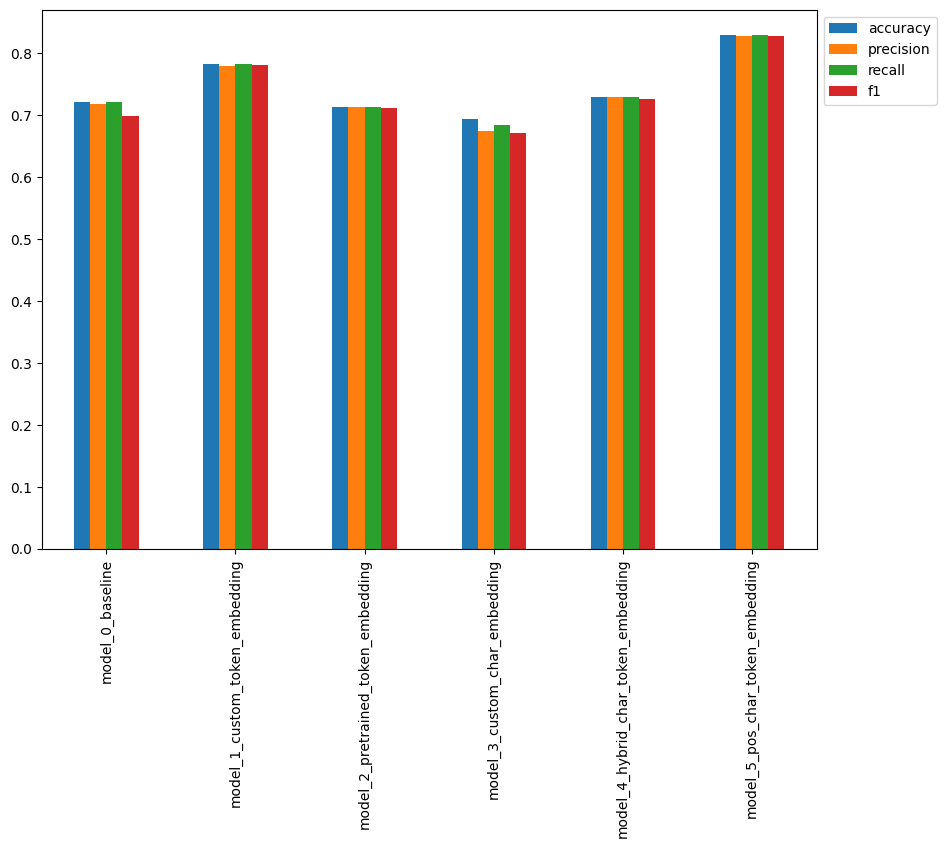

In [140]:
# Plot and compare all model results
all_model_results.plot(kind="bar",figsize=(10,7)).legend(bbox_to_anchor=(1.0, 1.0));

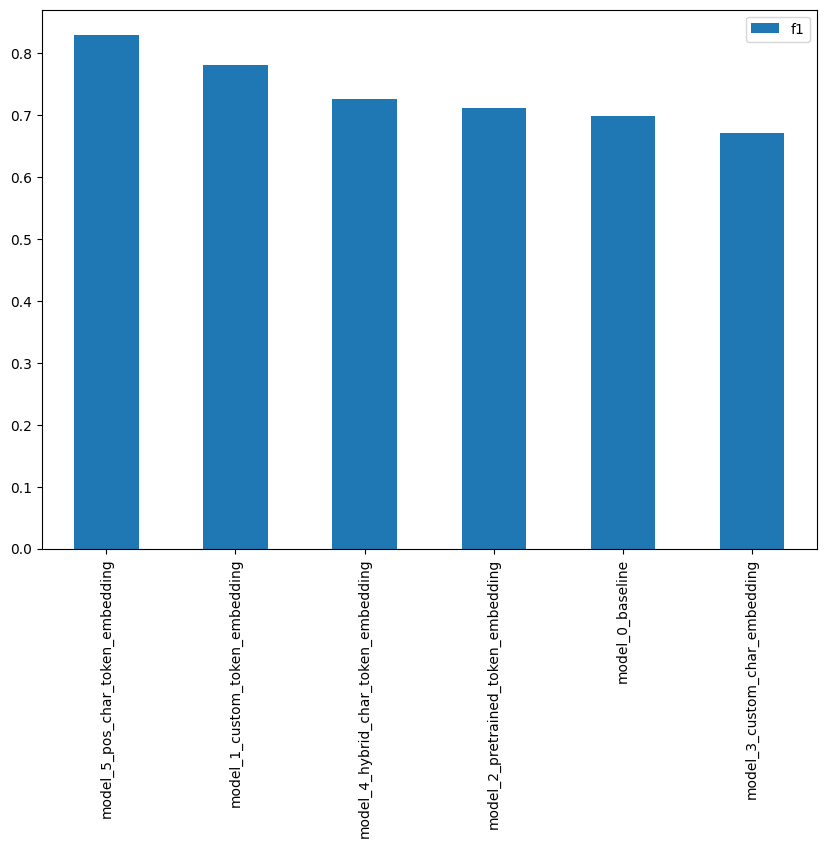

In [141]:
# Sort model reuslts by f1-score
all_model_results.sort_values("f1",ascending=False)["f1"].plot(kind="bar",figsize=(10,7)).legend(bbox_to_anchor=(1.0, 1.0))

## Root cause

```text
Custom layer (USELayer) is NOT properly serializable
```

Two separate issues:

---

# 1. Deserialization failure

```text
USELayer cannot be reconstructed from config
```

Because:

```text
hub.KerasLayer is created inside __init__
but not saved in get_config()
```

---

# 2. GPU copy error

```text
Failed copying tensor CPU → GPU
```

Side effect of improper loading + TF Hub layer

---

# FIX (correct way)

## Step 1 — Fix USELayer

Add `get_config`

```python
@tf.keras.utils.register_keras_serializable()
class USELayer(tf.keras.layers.Layer):
    def __init__(self, trainable=False, **kwargs):
        super().__init__(**kwargs)
        self.trainable_flag = trainable
        self.use = hub.KerasLayer(
            "https://tfhub.dev/google/universal-sentence-encoder/4",
            trainable=trainable
        )

    def call(self, inputs):
        return self.use(inputs)

    def get_config(self):
        config = super().get_config()
        config.update({
            "trainable": self.trainable_flag
        })
        return config
```

---

## Step 2 — Load model properly

```python
loaded_model_5 = tf.keras.models.load_model(
    "model_5_tribrid_embedding.keras",
    custom_objects={"USELayer": USELayer}
)
```

---

# Alternative (better)

## Avoid custom wrapper completely

```python
use_layer = hub.KerasLayer(
    "https://tfhub.dev/google/universal-sentence-encoder/4",
    trainable=False,
    name="use_layer"
)
```

Then use directly:

```python
token_embeddings = use_layer(token_inputs)
```

---

## Why this is better

```text
TF Hub layer is already serializable
Your wrapper breaks serialization
```

---

# If error still persists

Force CPU load:

```python
with tf.device("/CPU:0"):
    loaded_model_5 = tf.keras.models.load_model(
        "model_5_tribrid_embedding.keras",
        custom_objects={"USELayer": USELayer}
    )
```

---

# Bottom line

```text
Problem is NOT your model
Problem is custom USELayer serialization
```

---

# Best practice

```text
Never wrap TF Hub layers unless necessary
```


Root issue: **TensorFlow Hub layer + GPU + deserialization**. Not your architecture.

Breakdown:

### 1. Why this error happens

* `USELayer` internally loads a **SavedModel from TF Hub**
* During `load_model()`, it tries to:

  * restore weights
  * move tensors CPU → GPU
* Fails at:

  ```
  Failed copying input tensor ... CPU → GPU
  Dst tensor is not initialized
  ```
* This is a **runtime state issue**, not a code bug

### 2. Your current state

* You:

  * changed model multiple times
  * redefined `USELayer`
  * trained partially
  * then loaded model

Result:

* TF graph + GPU memory = **corrupted / inconsistent**
* TF Hub layer reload fails

### 3. Reality

You cannot reliably fix this without resetting runtime.

### 4. Minimal fix (without restart — unstable workaround)

Force USE to run on CPU:

```python
class USELayer(tf.keras.layers.Layer):
    def __init__(self, trainable=False, **kwargs):
        super().__init__(**kwargs)
        with tf.device('/CPU:0'):
            self.use = hub.KerasLayer(
                "https://tfhub.dev/google/universal-sentence-encoder/4",
                trainable=trainable
            )

    def call(self, inputs):
        return self.use(inputs)
```

Then:

```python
loaded_model_5 = tf.keras.models.load_model(
    "model_5_tribrid_embedding.keras",
    custom_objects={"USELayer": USELayer},
    compile=False
)
```

### 5. Stable fix (correct way)

Restart runtime. Then:

1. Define `USELayer` once
2. Load model immediately
3. Do not redefine layers

### 6. Key takeaway (write in notebook)

* TF Hub layers are **stateful external graphs**
* They break easily during:

  * serialization
  * GPU transfer
  * multiple redefinitions
* Always:

  * register custom layer
  * avoid redefining it
  * reload in clean runtime

### 7. Hard truth

If using TF Hub inside custom layers:

* reproducibility ↓
* debugging complexity ↑
* deployment harder than pure Keras models


## Save and load model

In [143]:
model_5.save("model_5_tribrid_embedding.keras")

In [147]:
loaded_model_5 = tf.keras.models.load_model(
    "model_5_tribrid_embedding.keras",
    custom_objects={"USELayer": USELayer},
    compile = False
)
loaded_model_5.summary()

TypeError: <class 'keras.src.models.functional.Functional'> could not be deserialized properly. Please ensure that components that are Python object instances (layers, models, etc.) returned by `get_config()` are explicitly deserialized in the model's `from_config()` method.

config={'module': 'keras.src.models.functional', 'class_name': 'Functional', 'config': {}, 'registered_name': 'Functional', 'build_config': {'input_shape': None}, 'compile_config': None}.

Exception encountered: <class '__main__.USELayer'> could not be deserialized properly. Please ensure that components that are Python object instances (layers, models, etc.) returned by `get_config()` are explicitly deserialized in the model's `from_config()` method.

config={'module': None, 'class_name': 'USELayer', 'config': {'name': 'use_layer', 'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None}}, 'registered_name': 'Custom>USELayer', 'build_conf

## Download and load in a pretrained model

In [ ]:
import tensorflow as tf
import tensorflow_hub as hub
from tensorflow.keras.layers.experimental.preprocessing import TextVectorization

### Why TF Hub feels broken in TF 2.x

**1. Execution model changed**

* **TF 1.x** → static graphs
* **TF 2.x** → eager + dynamic graphs

TF Hub modules (especially older ones) were designed for **graph mode**.
Now in TF 2.x:

* graph is rebuilt repeatedly
* device placement (CPU/GPU) happens dynamically
  → leads to instability during load / training

---

**2. SavedModel vs Keras mismatch**

* TF Hub uses **SavedModel**
* Keras uses **Layer/Model abstraction**

Bridge = `hub.KerasLayer`
This bridge is:

* not fully transparent
* not fully serializable
* fragile during `model.save()` / `load_model()`

---

**3. GPU + external graph = conflict**

* Hub loads a **precompiled graph**
* Your model builds another graph
* TF tries to merge + move to GPU

Failure point:

```
CPU → GPU tensor copy
```

This is exactly your error:

```
Dst tensor is not initialized
```

---

**4. Serialization problem (core issue)**
Your custom layer:

```python
class USELayer(...)
```

* wraps a **non-Keras object (hub.KerasLayer)**
* Keras cannot fully reconstruct it from config

Result:

* works during training
* breaks during loading

---

### Why it worked better in TF 1.x

* everything was already graph-based
* no dynamic rebuilding
* no eager execution
* no repeated device placement

So TF Hub fit naturally there.

---

### Has TensorFlow shifted away from Hub?

Yes.

#### Old approach (what you're using)

* TF Hub modules (USE, etc.)
* feature extraction via external graphs

#### Modern approach

1. **KerasNLP**
2. **Transformers (HuggingFace)**
3. Native Keras preprocessing + embeddings

---

### Current recommended replacements

#### For sentence embeddings (instead of USE)

* `sentence-transformers` (PyTorch, stable)
* HuggingFace models (BERT, MiniLM, etc.)
* KerasNLP encoders

#### In TensorFlow ecosystem

* Prefer:

  * `tf.keras.layers.Embedding`
  * `TextVectorization`
  * or KerasNLP models

Avoid:

* TF Hub inside custom layers for production

---

### Practical conclusion (write this)

* TF Hub is **not deprecated**, but:

  * poorly integrated with modern Keras workflows
  * unstable with GPU + serialization
* TF 2.x prefers:

  * native Keras layers
  * or external libraries (Transformers)
* TF Hub is fine for:

  * quick experiments
* Not reliable for:

  * saving/loading complex models
  * multi-input architectures

---

### Real takeaway

Your issue is not misuse.
It is architectural friction between:

* TF Hub (static, external)
* TF 2.x Keras (dynamic, internal)

They don’t compose cleanly.


<body>
                <div class="container">
                <div class="row">
                <div class="col-md-10 col-md-offset-1">
                    <p class="lead"><p>Woah!!! What a project and a half...</p><p>Massive effort on making it all the way through!</p><p>I hope now you're starting to realise the power of multi-modal models. Specifically, combining the inputs from different kinds of data sources (in our case, token embeddings as well as engineered features) and seeing how much of a performance boost they can give your models.</p><p>I issued a big enough challenge in the last video (<strong>going further with more data</strong> and <strong>finding SkimLit's most wrong predictions</strong>).</p><p>I'd encourage you to give both of those a go before moving onto the next module.</p><p>As always, you can find the materials you'll need in the <a href="https://github.com/mrdbourke/tensorflow-deep-learning" rel="noopener noreferrer" target="_blank">course GitHub repo</a> under “Course materials”.</p><p>If you have any questions, be sure to <a href="https://github.com/mrdbourke/tensorflow-deep-learning/discussions" rel="noopener noreferrer" target="_blank">add them to the discussions page</a>.</p><p>Be sure to send a message to the #machinelearning-datascience channel on Discord and mention my name (@mrdbourke) of anything interesting you discover whilst learning more.</p><p>Let's now move on to another common data type in machine learning: time series!</p><p>- Daniel</p><p>Web: <a href="http://www.mrdbourke.com/" rel="noopener noreferrer" target="_blank">www.mrdbourke.com</a></p><p>YouTube: <a href="https://dbourke.link/youtube" rel="noopener noreferrer" target="_blank">https://dbourke.link/youtube</a></p></p>
                </div>
                </div>
                </div>
                <script src="https://maxcdn.bootstrapcdn.com/bootstrap/3.3.7/js/bootstrap.min.js" integrity="sha384-Tc5IQib027qvyjSMfHjOMaLkfuWVxZxUPnCJA7l2mCWNIpG9mGCD8wGNIcPD7Txa" crossorigin="anonymous"></script>
                </body>

### Core direction (TensorFlow 2.x compatible stack)

#### 1. Native Keras (foundation)

Learn:

* Functional API (multi-input like your model_5)
* Custom layers (proper serialization)
* tf.data pipelines

Source:

* TensorFlow → [https://www.tensorflow.org/guide/keras](https://www.tensorflow.org/guide/keras)

---

#### 2. KerasNLP (modern replacement for TF Hub in NLP)

Purpose:

* pretrained text models
* tokenizers
* embeddings fully integrated with Keras

Source:

* KerasNLP → [https://keras.io/keras_nlp/](https://keras.io/keras_nlp/)

Key things:

* BERT-style encoders
* no serialization issues
* GPU safe

---

#### 3. Hugging Face Transformers (industry standard)

This replaces USE completely.

Source:

* Hugging Face Transformers → [https://huggingface.co/docs/transformers](https://huggingface.co/docs/transformers)

What to learn:

* AutoTokenizer
* AutoModel / TFAutoModel
* sentence embeddings

Important:

* works with both PyTorch and TensorFlow
* far more stable than TF Hub

---

#### 4. Sentence Transformers (best for embeddings)

Direct replacement for USE.

Source:

* Sentence Transformers → [https://www.sbert.net/](https://www.sbert.net/)

Use when:

* you only need embeddings
* not full training pipeline

---

#### 5. tf.data mastery (critical for performance)

You already use it but not deeply.

Learn:

* map()
* cache()
* prefetch()
* multi-input pipelines (for your tribrid model)

Source:

* TensorFlow → [https://www.tensorflow.org/guide/data](https://www.tensorflow.org/guide/data)

---

### Correct learning order

1. Keras Functional API (deep mastery)
2. tf.data (multi-input pipelines)
3. KerasNLP (for TensorFlow-native NLP)
4. HuggingFace Transformers (real-world standard)
5. Sentence Transformers (fast embedding usage)

---

### What to stop using

* TF Hub (for complex models)
* custom wrappers around external models (like USELayer)

---

### Minimal modern stack (clean + stable)

* Text preprocessing → `TextVectorization` or tokenizer
* Embedding → KerasNLP / Transformers
* Model → Keras Functional API
* Data → tf.data

---

### Final directive

Your current path (multi-input hybrid model) is correct.
Replace only this component:

```
USELayer ❌ → KerasNLP / Transformers ✅
```

Everything else in your architecture remains valid.


### Phase 0 — Foundation (mandatory)

* Python (clean OOP, generators, decorators)
* NumPy (vectorization mindset)
* Math:

  * Linear algebra (matrix ops, eigenvalues)
  * Probability (distributions, expectation)
  * Optimization (gradients)

---

### Phase 1 — Core Deep Learning (TensorFlow 2.x)

Focus:

* Keras Functional API (multi-input, custom models)
* Custom layers (serialization-safe)
* Loss functions, metrics
* Training loops (fit + custom training step)

Learn from:

* TensorFlow

Outcome:

* You can build any architecture without hacks

---

### Phase 2 — Data Pipelines (critical bottleneck skill)

Focus:

* `tf.data` deep usage:

  * map / batch / prefetch / cache
  * multi-input pipelines (like your tribrid model)
* handling large datasets

Outcome:

* No training bottlenecks

---

## NLP TRACK

### Phase 3A — Modern NLP (replace TF Hub)

#### Step 1: Keras-native NLP

* KerasNLP
  Learn:
* tokenizers
* pretrained encoders
* text classification pipelines

#### Step 2: Industry standard

* Hugging Face Transformers

Learn:

* AutoTokenizer
* TFAutoModel / AutoModel
* fine-tuning BERT

#### Step 3: Embeddings specialization

* Sentence Transformers

Outcome:

* Replace USE completely
* Stable, production-ready NLP

---

## COMPUTER VISION TRACK

### Phase 3B — Core CV

Start with CNN fundamentals:

* Conv2D, pooling
* feature maps
* transfer learning

Use:

* `tf.keras.applications`

---

### Phase 4B — Transfer Learning (mandatory)

Models:

* ResNet
* EfficientNet
* MobileNet

Learn:

* freezing vs fine-tuning
* feature extraction vs full training

Outcome:

* fast high-accuracy models

---

### Phase 5B — Advanced CV

Tasks:

* Image classification (baseline)
* Object detection
* Segmentation

Libraries:

* TensorFlow Object Detection API
* OpenCV

---

### Phase 6B — Modern CV (industry)

* Vision Transformers (ViT)
* Multimodal models

Use:

* Hugging Face Transformers

---

## UNIFICATION PHASE (important)

### Phase 7 — Multimodal systems

What you already started (very important):

* text + char + positional → NLP hybrid
  Extend to:
* image + text models

Outcome:

* high-level system design ability

---

## ENGINEERING PHASE

### Phase 8 — Model deployment

* TensorFlow SavedModel
* FastAPI
* ONNX (optional)

---

### Phase 9 — Optimization

* mixed precision
* batching strategies
* GPU utilization

---

## FINAL STRUCTURE

```
Foundation
   ↓
Core TF/Keras
   ↓
tf.data mastery
   ↓
Split:
   NLP (Transformers)
   CV (CNN + Transfer Learning)
   ↓
Advanced (ViT / Multimodal)
   ↓
Deployment + Optimization
```

---

## Critical corrections to your current path

* Remove:

  * TF Hub
  * custom wrapper hacks

* Keep:

  * multi-input architectures
  * tf.data pipelines
  * hybrid embeddings

---

## End state capability

* Build:

  * BERT-based NLP models
  * ResNet/EfficientNet CV models
  * hybrid multimodal systems
* Train, debug, and deploy without framework issues
